# CSD estimation analysis — E. coli (Ecoli_Analysis_Notebooks/estimation)

This notebook aggregates per-edge CSV outputs from

`notebooks/Ecoli_Analysis_Notebooks/estimation/20260708_161623/csv`.

It produces plots showing:

1. **Estimated path coefficient** vs **ground-truth beta**
2. **Error metrics** (MAE / RMSE / bias) across simulation parameters
3. **Residual variance** changes with parameters, and its relationship to error


In [5]:
from __future__ import annotations

from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

from IPython.display import Image, display

REPO = Path().resolve()
while not (REPO / 'src' / 'nocap').exists() and REPO != REPO.parent:
    REPO = REPO.parent

INPUT_DIR = REPO / '/home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/csv'
NB_DIR = INPUT_DIR.parent
VIZ_DIR = REPO / NB_DIR / 'visualizations'
VIZ_DIR.mkdir(exist_ok=True)

print('Input CSV dir:', INPUT_DIR)
csv_paths = sorted(INPUT_DIR.glob('*.csv'))
print('Num CSV files:', len(csv_paths))
assert len(csv_paths) > 0, f'No CSVs found in: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/csv'
print('First CSV:', csv_paths[0].name)


Input CSV dir: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/csv
Num CSV files: 12
First CSV: csd_estimate_mech_MCAR_edge_0p0_data_0p0_n_100-500-1000-5000-10000-50000-100000.csv


In [6]:
# ============================================================
# Load and derive error columns
# ============================================================

dfs = []
for p in csv_paths:
    df = pd.read_csv(p)
    df['csv_file'] = p.name
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)

print('Total rows:', f"{len(data):,}")
print('Status counts:')
print(data['status'].value_counts())

for col in [
    'estimated_path_coefficient',
    'stderr',
    'residual_variance',
    'ground_truth_beta',
]:
    data[col] = pd.to_numeric(data[col], errors='coerce')

# Core derived metrics
data['error'] = data['estimated_path_coefficient'] - data['ground_truth_beta']
data['abs_error'] = data['error'].abs()
data['sq_error'] = data['error'] ** 2

# Relative slope error: absolute error normalized by ground-truth beta
# (guard against division by zero / non-finite values)
data['relative_slope_error'] = data['abs_error'] / data['ground_truth_beta']
data.loc[~np.isfinite(data['relative_slope_error']), 'relative_slope_error'] = np.nan

eval_df = data[data['status'].isin(['identifiable', 'insufficient_data'])].copy()
print('Eval rows:', f"{len(eval_df):,}")


def summarize(df: pd.DataFrame) -> dict[str, float]:
    mae = float(df['abs_error'].mean())
    rmse = float(np.sqrt(df['sq_error'].mean()))
    bias = float(df['error'].mean())
    med_abs = float(df['abs_error'].median())
    rel_mean = float(df['relative_slope_error'].mean())
    rel_median = float(df['relative_slope_error'].median())
    return {
        'MAE': mae,
        'RMSE': rmse,
        'bias': bias,
        'median_abs_error': med_abs,
        'relative_slope_error_mean': rel_mean,
        'relative_slope_error_median': rel_median,
    }


overall = summarize(eval_df)
print('Overall estimation metrics (across all CSVs):')
for k, v in overall.items():
    print(f"  {k}: {v:.6g}")


Total rows: 212,940
Status counts:
status
identifiable         188773
insufficient_data     24025
estimation_error        142
Name: count, dtype: int64
Eval rows: 212,798
Overall estimation metrics (across all CSVs):
  MAE: 0.0429444
  RMSE: 0.0745053
  bias: 0.0214798
  median_abs_error: 0.0225216
  relative_slope_error_mean: 0.322356
  relative_slope_error_median: 0.1631


## 1) Estimated beta vs ground-truth beta

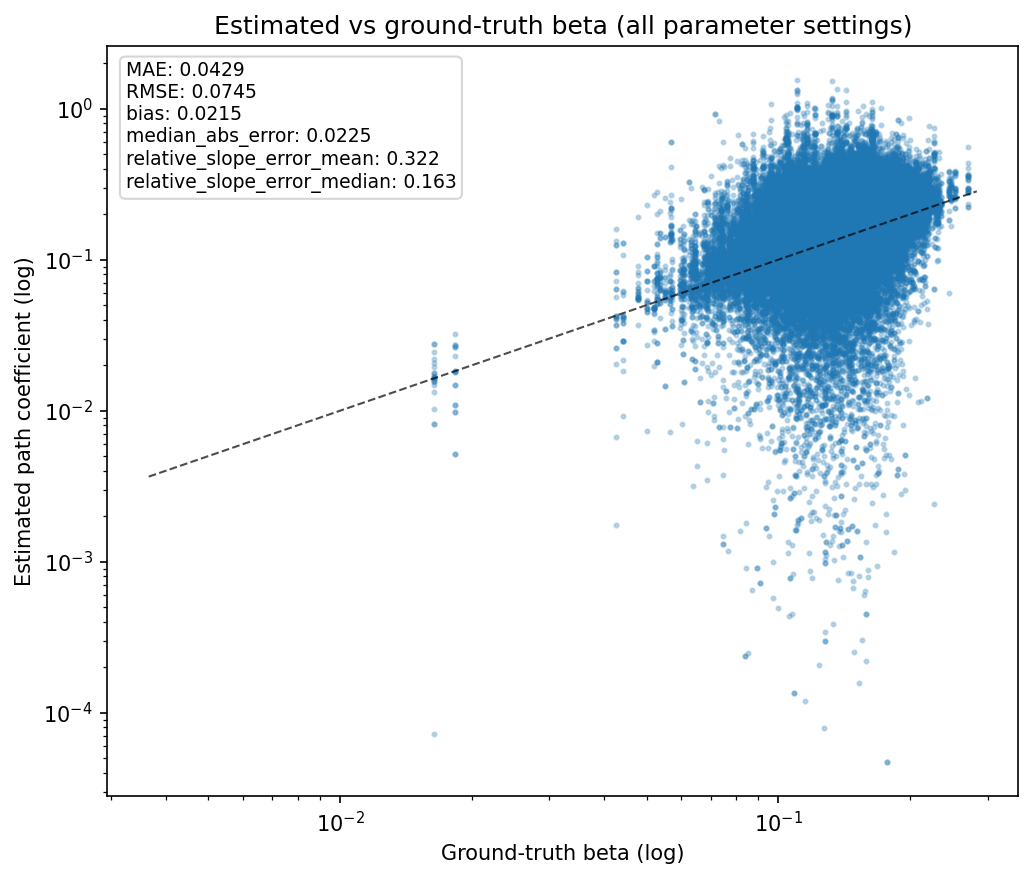

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_beta_scatter.png


In [7]:
# Scatter plot + y=x reference line
plot_df = eval_df.dropna(subset=['ground_truth_beta', 'estimated_path_coefficient']).copy()

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_xscale('log')
ax.set_yscale('log')
ax.scatter(
    plot_df['ground_truth_beta'],
    plot_df['estimated_path_coefficient'],
    s=4,
    alpha=0.25,
    rasterized=True,
)

lims = [
    float(plot_df['ground_truth_beta'].min()),
    float(plot_df['ground_truth_beta'].max()),
]
pad = 0.05 * (lims[1] - lims[0] + 1e-12)
lo, hi = lims[0] - pad, lims[1] + pad
ax.plot([lo, hi], [lo, hi], color='black', linewidth=1, linestyle='--', alpha=0.7)

ax.set_xlabel('Ground-truth beta (log)')
ax.set_ylabel('Estimated path coefficient (log)')
ax.set_title('Estimated vs ground-truth beta (all parameter settings)')

note = '\n'.join([f"{k}: {v:.3g}" for k, v in overall.items()])
ax.text(
    0.02,
    0.98,
    note,
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='0.8'),
)

plt.tight_layout()
out = VIZ_DIR / 'csd_estimation_beta_scatter.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.close()

display(Image(str(out)))
print(f'Saved: {out}')


## 1b) Relative slope error (|estimated-true| / true) vs ground-truth beta

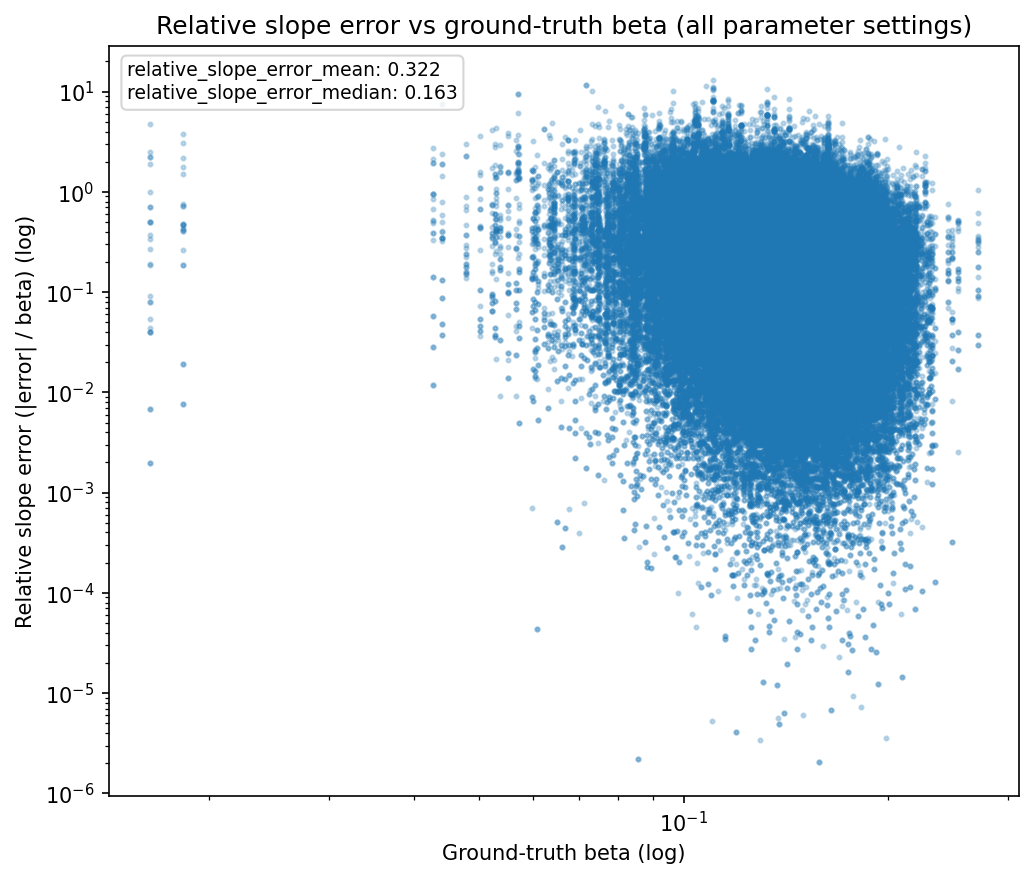

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_relative_slope_error_scatter.png


In [8]:
# Scatter plot: relative_slope_error vs ground-truth beta
plot_df = eval_df.dropna(subset=['ground_truth_beta', 'relative_slope_error']).copy()
plot_df = plot_df[np.isfinite(plot_df['relative_slope_error'])]

fig, ax = plt.subplots(figsize=(7, 6))
ax.set_xscale('log')
ax.set_yscale('log')
ax.scatter(
    plot_df['ground_truth_beta'],
    plot_df['relative_slope_error'],
    s=4,
    alpha=0.25,
    rasterized=True,
)

ax.set_xlabel('Ground-truth beta (log)')
ax.set_ylabel('Relative slope error (|error| / beta) (log)')
ax.set_title('Relative slope error vs ground-truth beta (all parameter settings)')

note = '\n'.join([f"{k}: {v:.3g}" for k, v in overall.items() if k.startswith('relative_slope_error')])
ax.text(
    0.02,
    0.98,
    note,
    transform=ax.transAxes,
    va='top',
    ha='left',
    fontsize=9,
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='0.8'),
)

plt.tight_layout()
out = VIZ_DIR / 'csd_estimation_relative_slope_error_scatter.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.close()

display(Image(str(out)))
print(f'Saved: {out}')


## 2) Error-metric breakdown across simulation parameters

Wrote error summary: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/csd_estimation_error_summary.csv


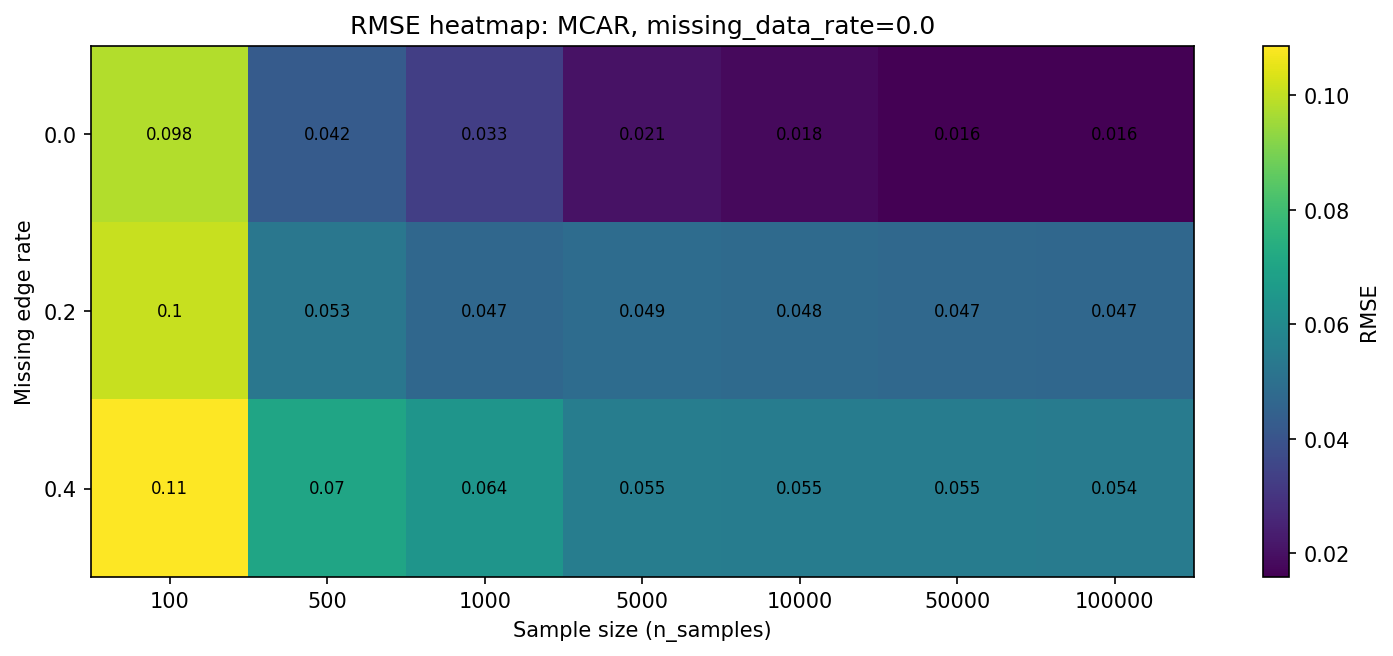

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_RMSE_heatmap_MCAR_data_rate0.0.png


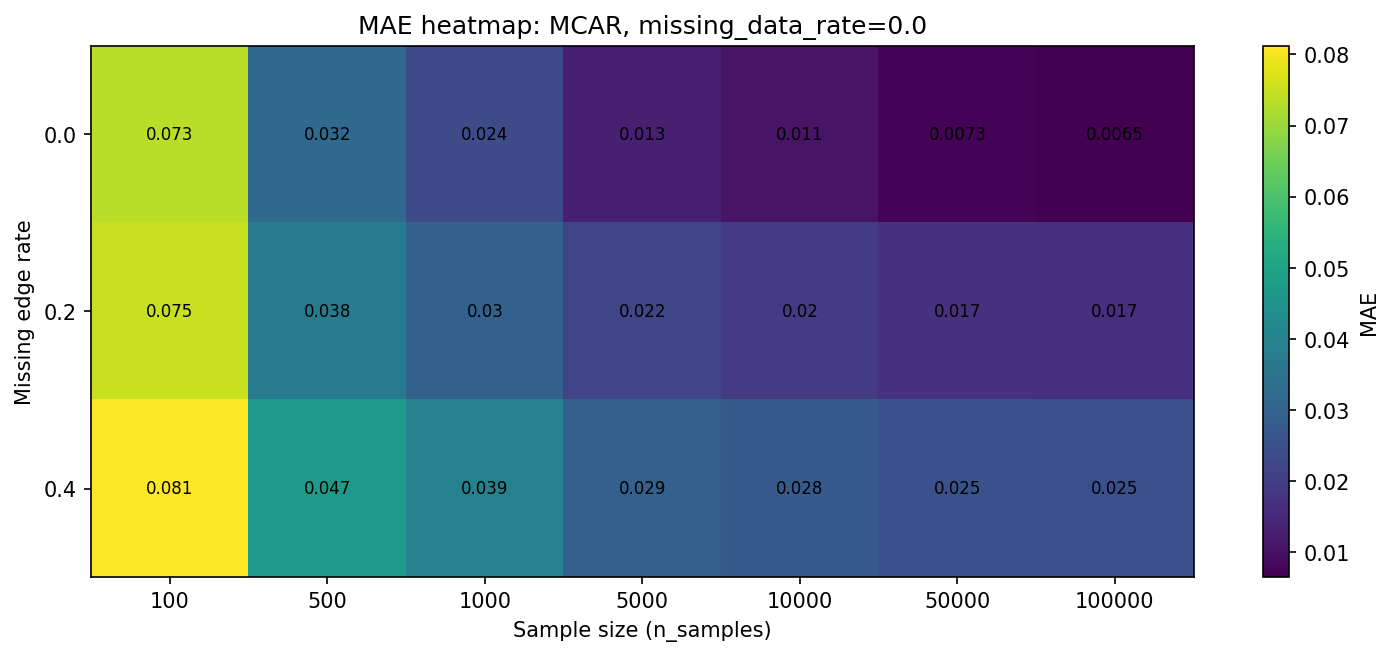

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_MAE_heatmap_MCAR_data_rate0.0.png


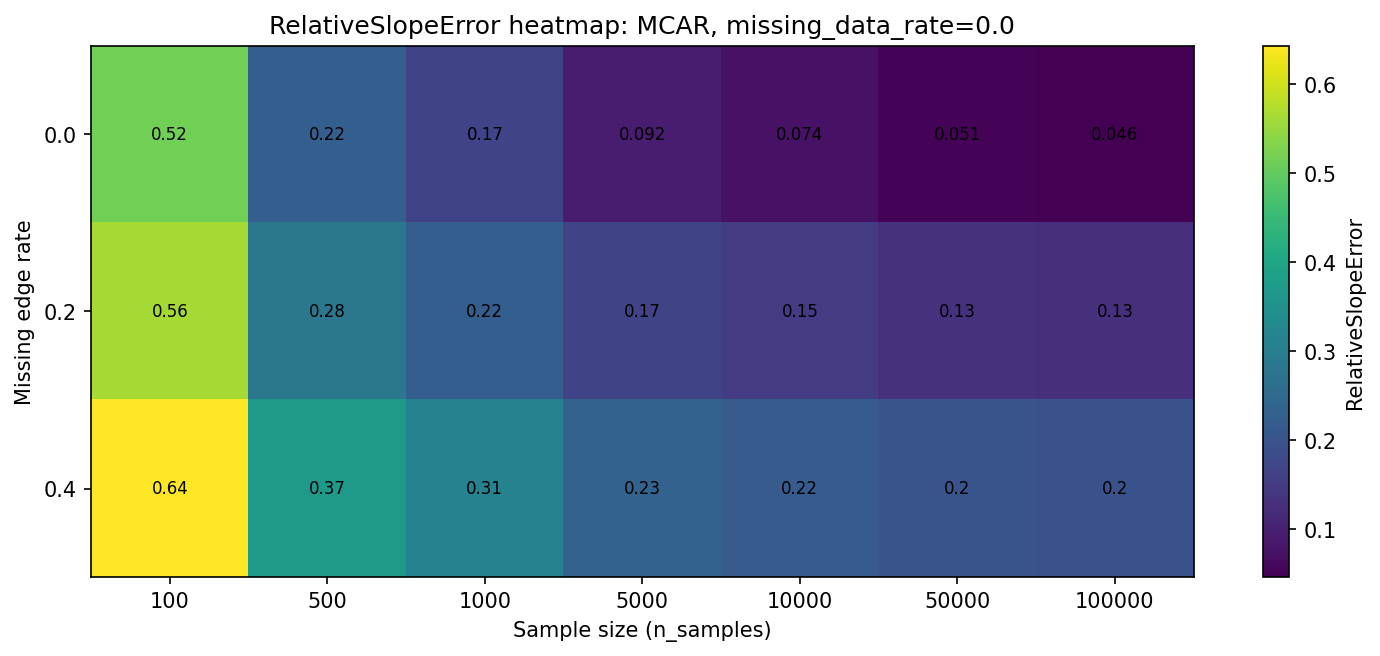

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_RelativeSlopeError_heatmap_MCAR_data_rate0.0.png


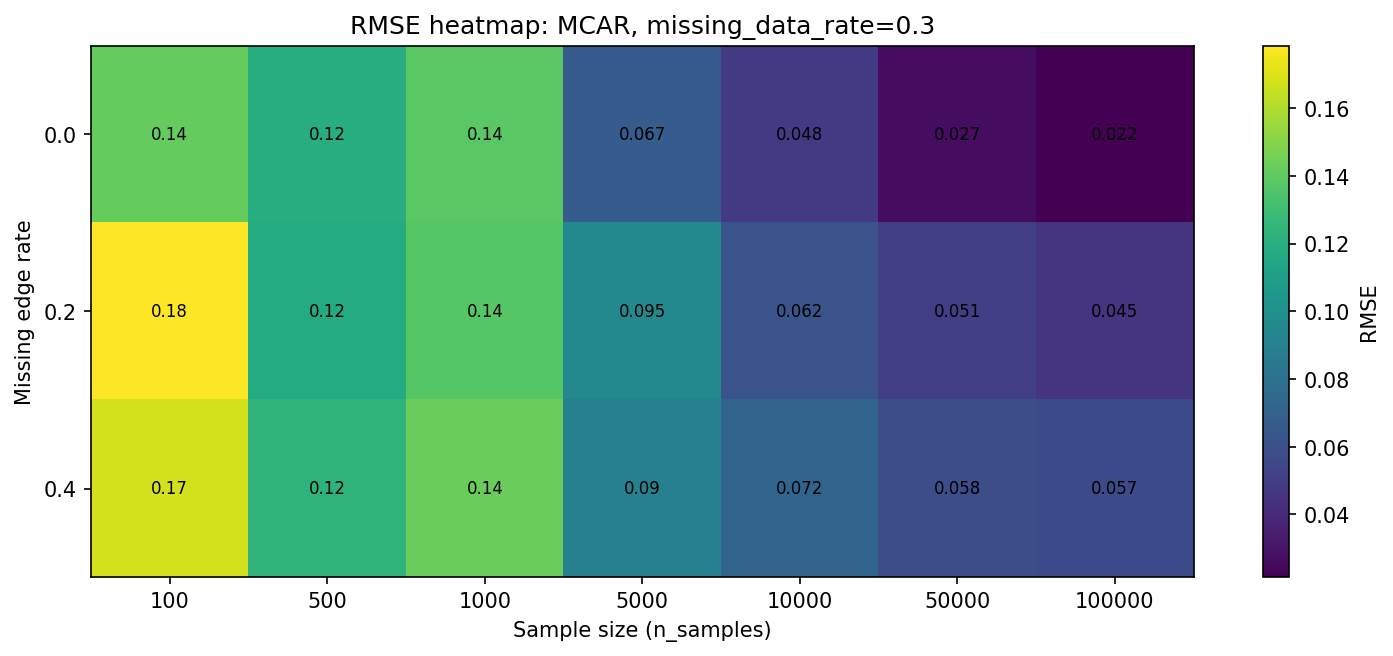

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_RMSE_heatmap_MCAR_data_rate0.3.png


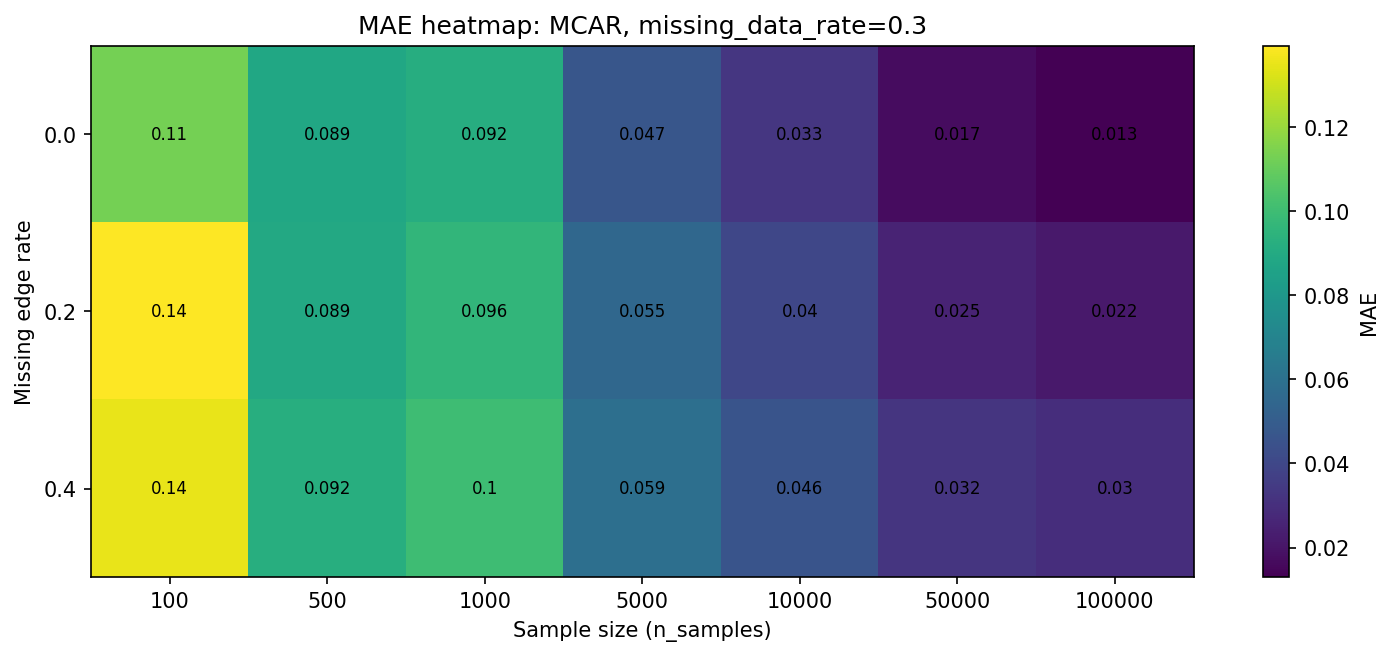

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_MAE_heatmap_MCAR_data_rate0.3.png


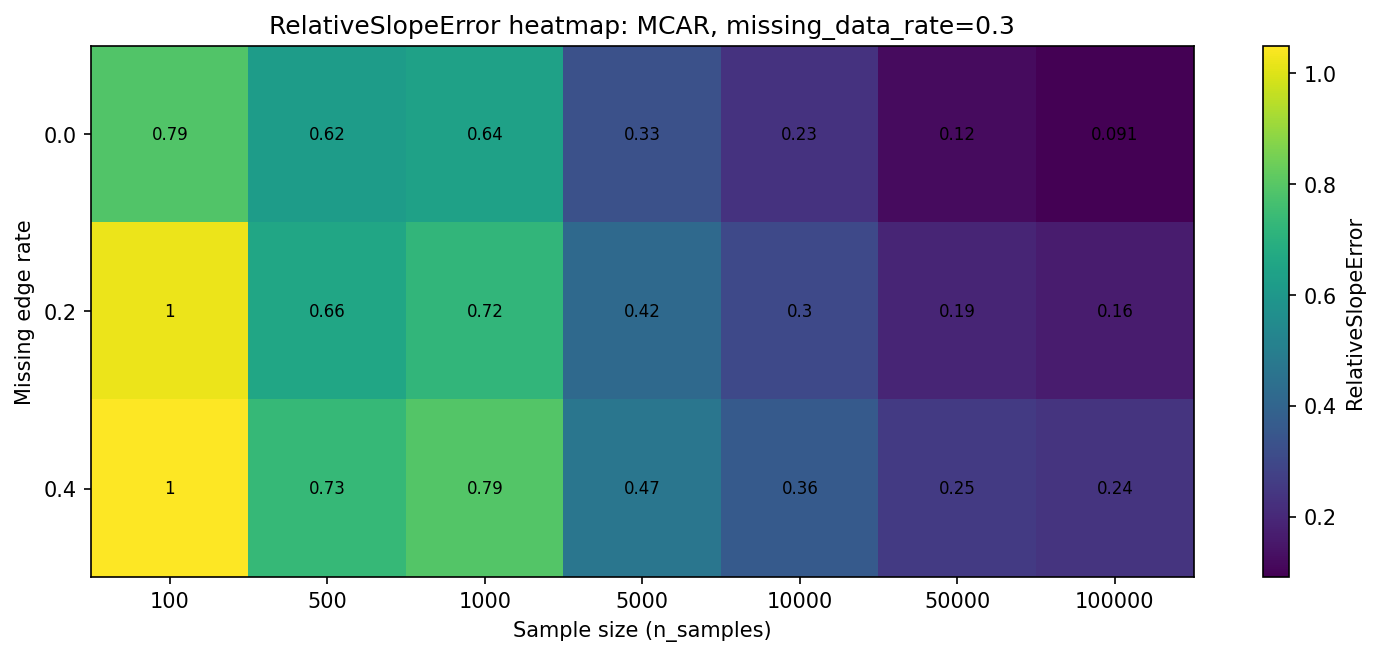

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_RelativeSlopeError_heatmap_MCAR_data_rate0.3.png


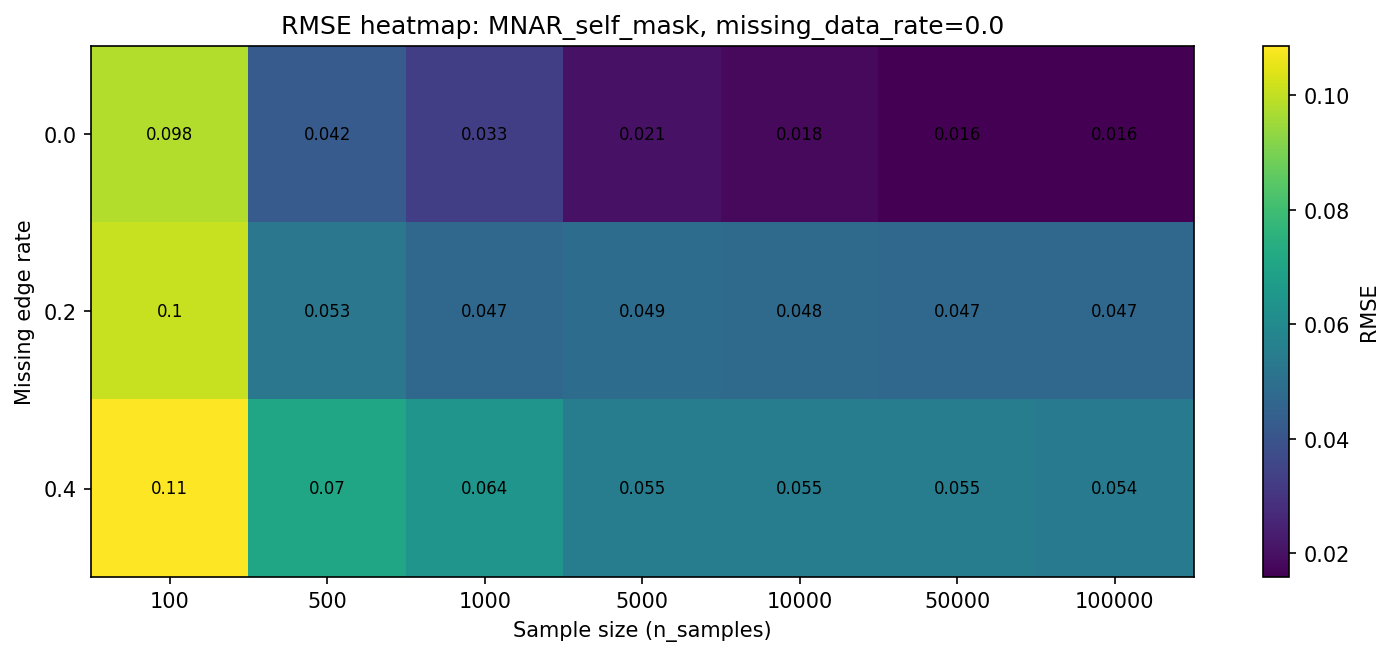

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_RMSE_heatmap_MNAR_self_mask_data_rate0.0.png


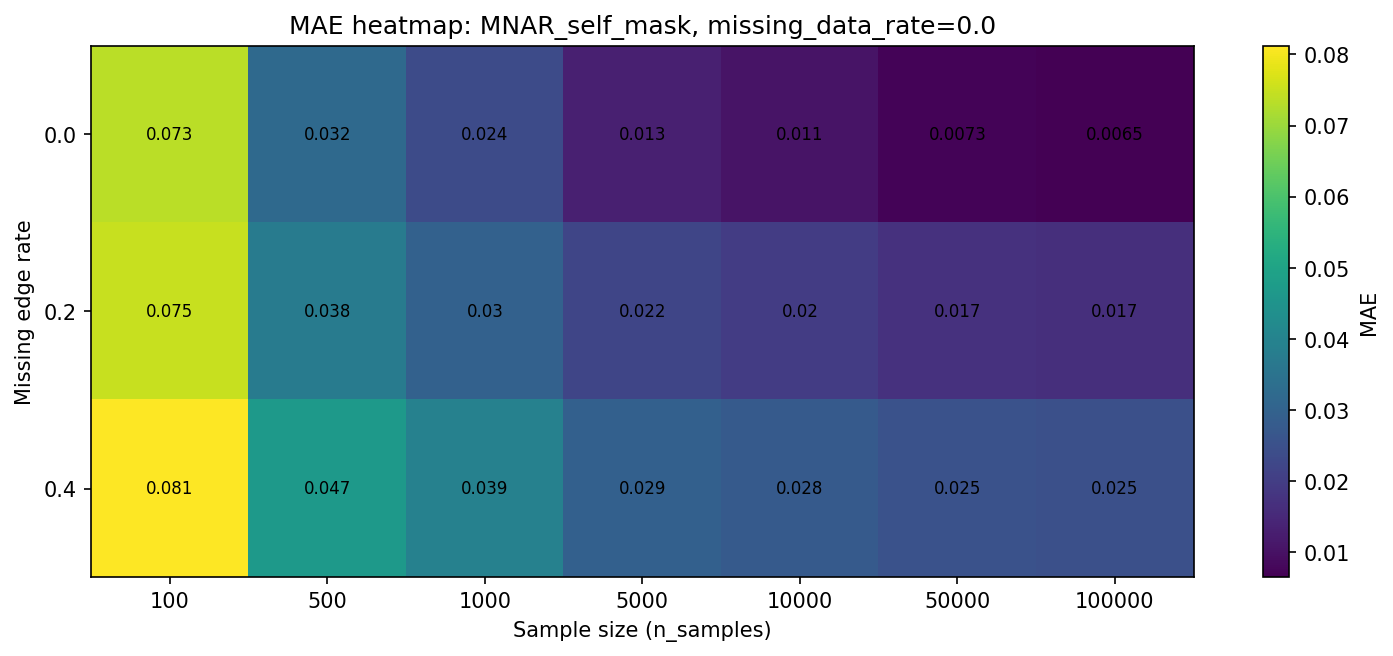

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_MAE_heatmap_MNAR_self_mask_data_rate0.0.png


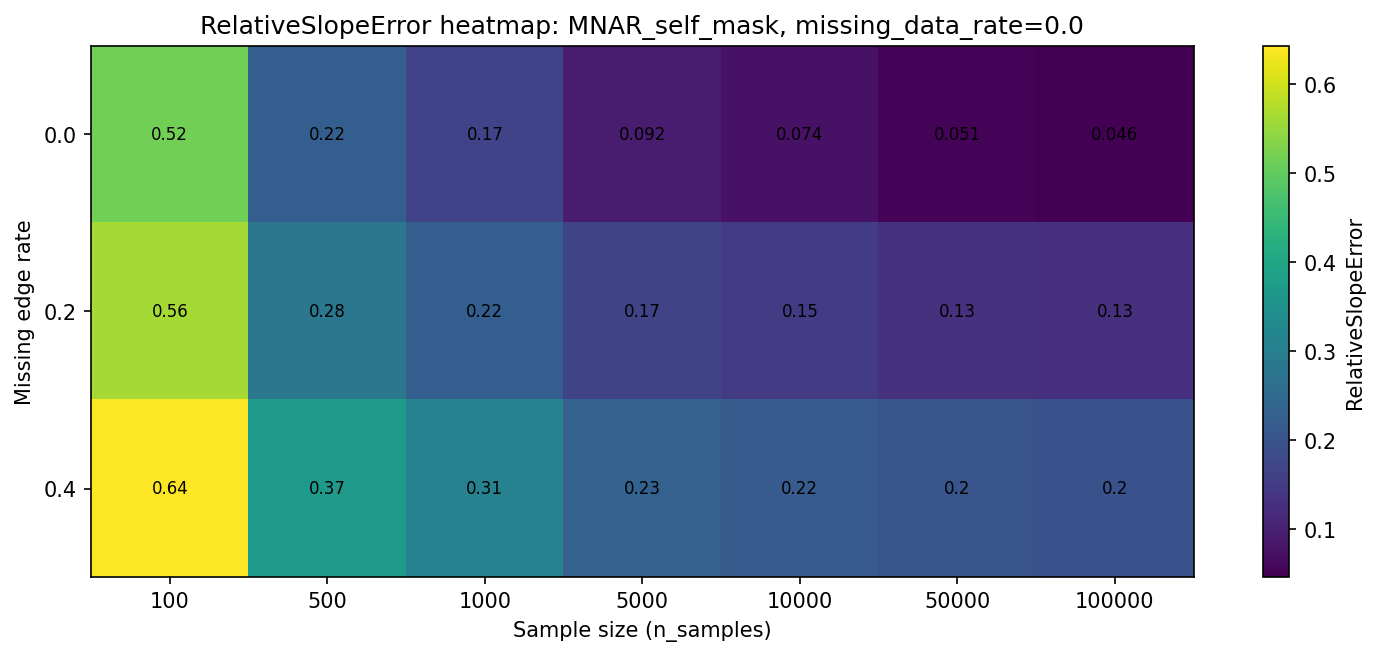

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_RelativeSlopeError_heatmap_MNAR_self_mask_data_rate0.0.png


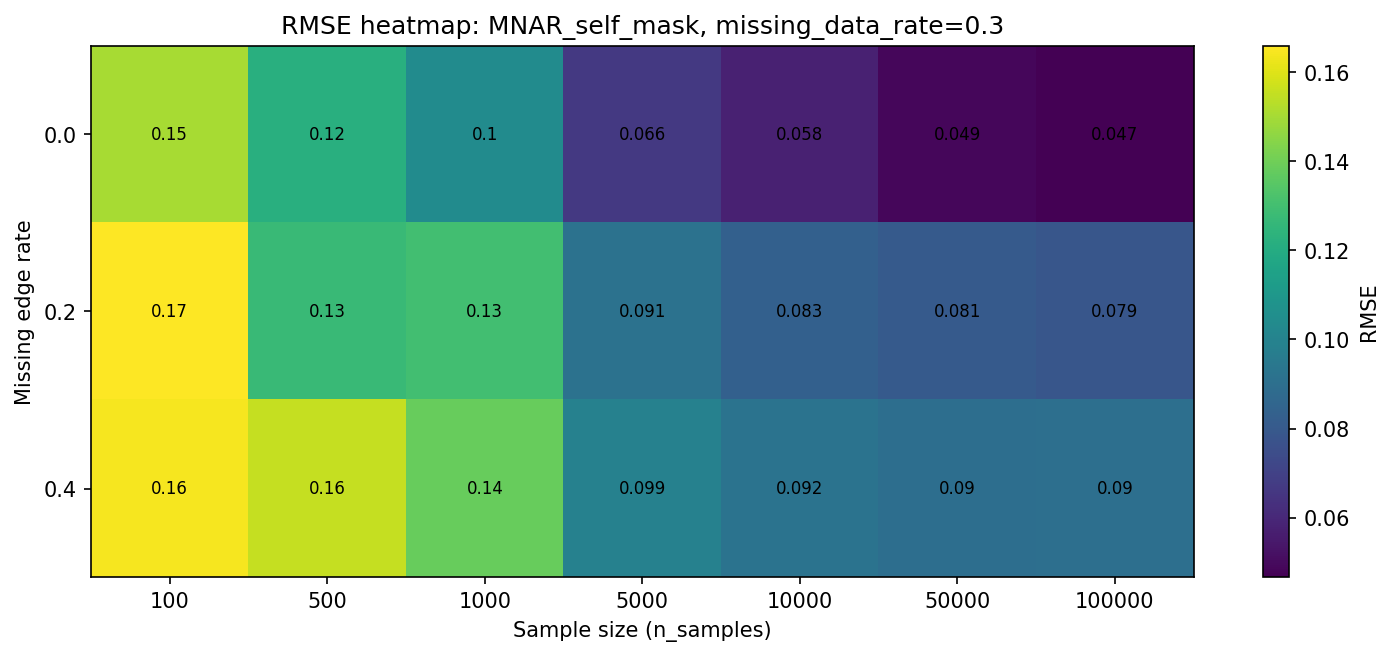

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_RMSE_heatmap_MNAR_self_mask_data_rate0.3.png


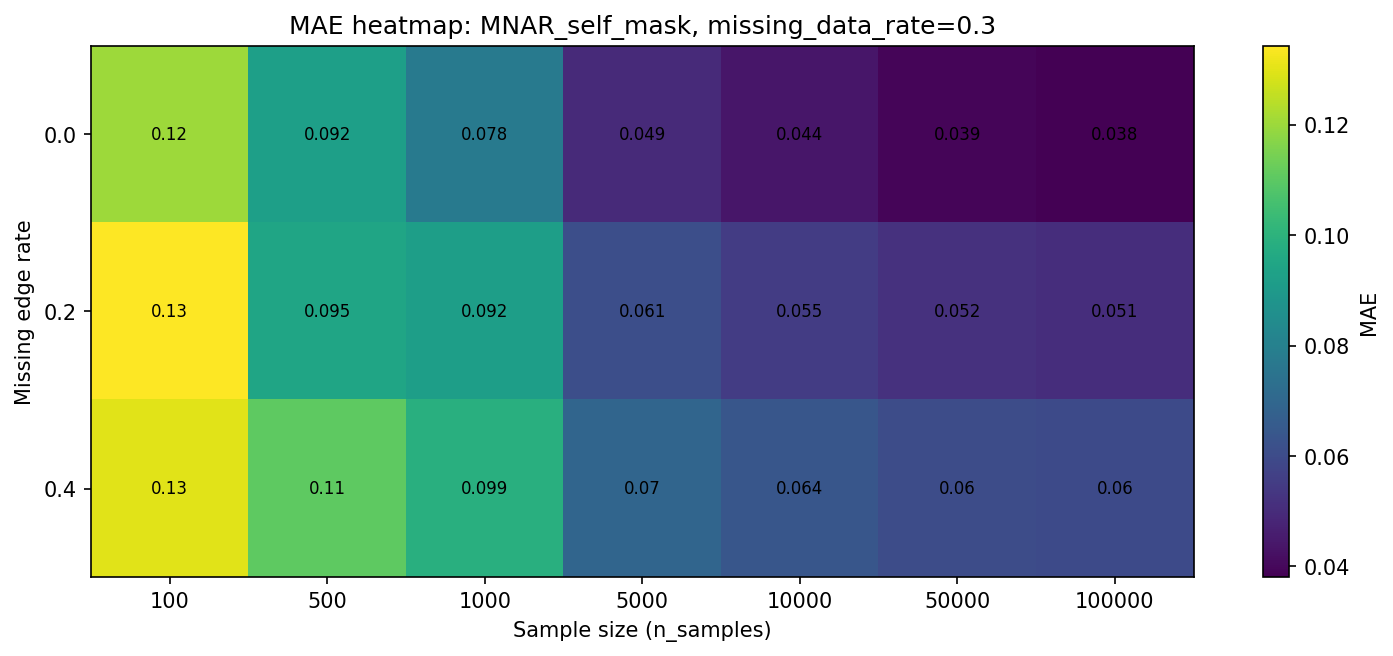

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_MAE_heatmap_MNAR_self_mask_data_rate0.3.png


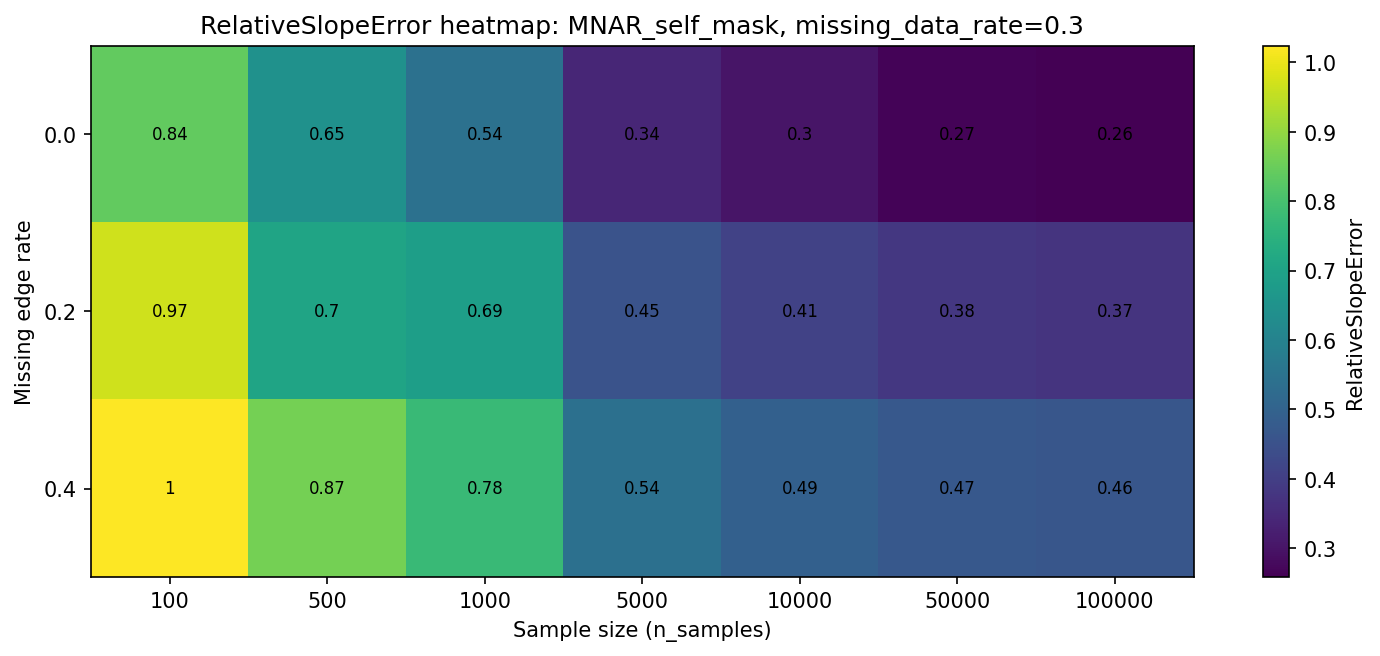

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_RelativeSlopeError_heatmap_MNAR_self_mask_data_rate0.3.png


In [9]:
# Grouped metrics
group_cols = [
    'missing_data_mechanism',
    'missing_data_rate',
    'missing_edge_rate',
    'n_samples',
]

g = (
    eval_df.groupby(group_cols, dropna=False)
    .agg(
        n=('error', 'size'),
        MAE=('abs_error', 'mean'),
        RMSE=('sq_error', lambda x: float(np.sqrt(np.mean(x)))),
        bias=('error', 'mean'),
        median_abs_error=('abs_error', 'median'),
        RelativeSlopeError=('relative_slope_error', 'mean'),
    )
    .reset_index()
)

err_summary_csv = NB_DIR / 'csd_estimation_error_summary.csv'
g.to_csv(err_summary_csv, index=False)
print(f'Wrote error summary: {err_summary_csv}')


def plot_metric_heatmap(mechanism: str, data_rate: float, metric: str = 'RMSE'):
    sub = g[(g['missing_data_mechanism'] == mechanism) & (g['missing_data_rate'] == data_rate)]
    if len(sub) == 0:
        print('No data for:', mechanism, data_rate)
        return

    pivot = (
        sub.pivot_table(
            index='missing_edge_rate',
            columns='n_samples',
            values=f'{metric}',
            aggfunc='mean',
        )
        .sort_index(axis=0)
        .sort_index(axis=1)
    )

    fig, ax = plt.subplots(figsize=(10, 4.5))
    im = ax.imshow(pivot.values, aspect='auto', interpolation='nearest')

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(v) for v in pivot.index])
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels([str(v) for v in pivot.columns])

    ax.set_xlabel('Sample size (n_samples)')
    ax.set_ylabel('Missing edge rate')
    ax.set_title(f'{metric} heatmap: {mechanism}, missing_data_rate={data_rate}')

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(f'{metric}')

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if np.isfinite(val):
                ax.text(j, i, f'{val:.2g}', ha='center', va='center', fontsize=8, color='black')

    plt.tight_layout()
    out = VIZ_DIR / f'csd_estimation_{metric}_heatmap_{mechanism}_data_rate{data_rate}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.close()
    display(Image(str(out)))
    print(f'Saved: {out}')


mechs = sorted(eval_df['missing_data_mechanism'].unique())
data_rates = sorted(eval_df['missing_data_rate'].unique())

for mech in mechs:
    for dr in data_rates:
        plot_metric_heatmap(mech, float(dr), 'RMSE')
        plot_metric_heatmap(mech, float(dr), 'MAE')
        plot_metric_heatmap(mech, float(dr), 'RelativeSlopeError')


## 2b) Adjustment set size affects error metrics (pipeline sparsity)

The `adjustment_set` column contains a pipe-separated list of adjustment nodes.
We compute its size and show how MAE/RMSE/bias (and residual variance) change as
the adjustment set gets larger.


Wrote adjustment-set-size summary: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/csd_estimation_adjustment_set_size_summary.csv


,adjustment_set_size,n,MAE,RMSE,bias,residual_mean,residual_median
0,1,8736,0.036728,0.062000,0.013310,1.089442,1.025960
1,2,14028,0.031675,0.052497,0.010197,1.083140,1.025985
2,3,17136,0.031154,0.049866,0.009415,1.079911,1.030560
3,4,15960,0.032431,0.054603,0.007848,1.052246,1.023394
4,5,13944,0.036287,0.061143,0.010236,1.045847,1.021007
5,6,11508,0.035495,0.061337,0.008068,1.029792,1.015478
6,7,23940,0.080817,0.136466,0.055981,1.967505,1.190896
7,8,75542,0.044514,0.069468,0.029719,1.129424,1.027944
8,9,11844,0.033887,0.057453,0.008254,1.043208,1.008029
9,10,4032,0.035412,0.062878,-0.001357,1.002338,1.001872


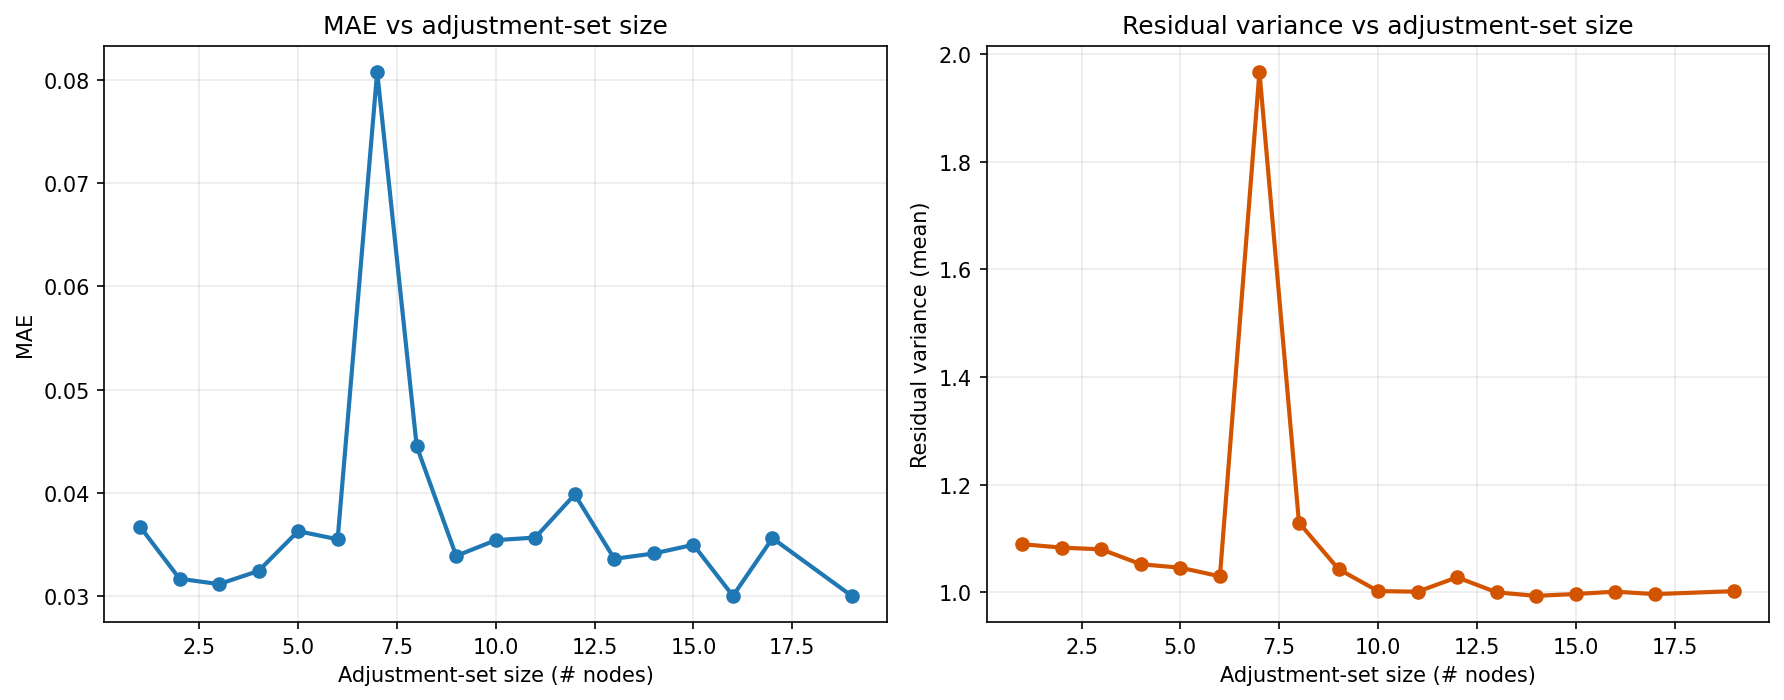

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_mae_resid_vs_adjustment_set_size.png


In [10]:
# Compute adjustment-set size from the pipe-separated adjustment_set string
def adj_set_size(s) -> float:
    if pd.isna(s):
        return float('nan')
    parts = str(s).split('|')
    parts = [p for p in parts if p]
    return float(len(parts))

eval_tmp = eval_df.copy()
eval_tmp['adjustment_set_size'] = eval_tmp['adjustment_set'].apply(adj_set_size)

eval_tmp = eval_tmp.dropna(subset=['adjustment_set_size'])
eval_tmp['adjustment_set_size'] = eval_tmp['adjustment_set_size'].astype(int)

adj_summary = (
    eval_tmp.groupby('adjustment_set_size', dropna=False)
    .agg(
        n=('error', 'size'),
        MAE=('abs_error', 'mean'),
        RMSE=('sq_error', lambda x: float(np.sqrt(np.mean(x)))),
        bias=('error', 'mean'),
        residual_mean=('residual_variance', 'mean'),
        residual_median=('residual_variance', 'median'),
    )
    .reset_index()
    .sort_values('adjustment_set_size')
)

adj_csv = NB_DIR / 'csd_estimation_adjustment_set_size_summary.csv'
adj_summary.to_csv(adj_csv, index=False)
print(f'Wrote adjustment-set-size summary: {adj_csv}')

display(adj_summary.head(20))

# Plot MAE and residual variance vs adjustment set size
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

axes[0].plot(adj_summary['adjustment_set_size'], adj_summary['MAE'], marker='o', linewidth=2)
axes[0].set_xlabel('Adjustment-set size (# nodes)')
axes[0].set_ylabel('MAE')
axes[0].set_title('MAE vs adjustment-set size')
axes[0].grid(True, alpha=0.25)

axes[1].plot(adj_summary['adjustment_set_size'], adj_summary['residual_mean'], marker='o', linewidth=2, color='#d35400')
axes[1].set_xlabel('Adjustment-set size (# nodes)')
axes[1].set_ylabel('Residual variance (mean)')
axes[1].set_title('Residual variance vs adjustment-set size')
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
out = VIZ_DIR / 'csd_estimation_mae_resid_vs_adjustment_set_size.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.close()

display(Image(str(out)))
print(f'Saved: {out}')


Filtered rows: 10,132
Wrote adjustment-set-size summary: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/csd_estimation_adjustment_set_size_summary_no_missing_n_gt10000.csv


,adjustment_set_size,n,MAE,RMSE,bias,residual_mean,residual_median
0,1,416,0.003347,0.005621,0.000316,1.000847,1.000133
1,2,668,0.004453,0.008091,0.001529,1.014949,1.000796
2,3,816,0.005160,0.010714,0.002651,1.020166,1.001198
3,4,760,0.005714,0.009935,0.002867,1.012768,1.000428
4,5,664,0.008811,0.015541,0.006823,1.023022,1.002373
5,6,548,0.007637,0.012884,0.005711,1.014201,1.002539
6,7,1140,0.017931,0.033624,0.016681,2.077172,1.120776
7,8,3596,0.005613,0.014328,0.003863,1.063742,1.000589
8,9,564,0.004336,0.008034,0.002162,1.028498,1.000306
9,10,192,0.003242,0.003888,0.000815,0.999201,0.999190


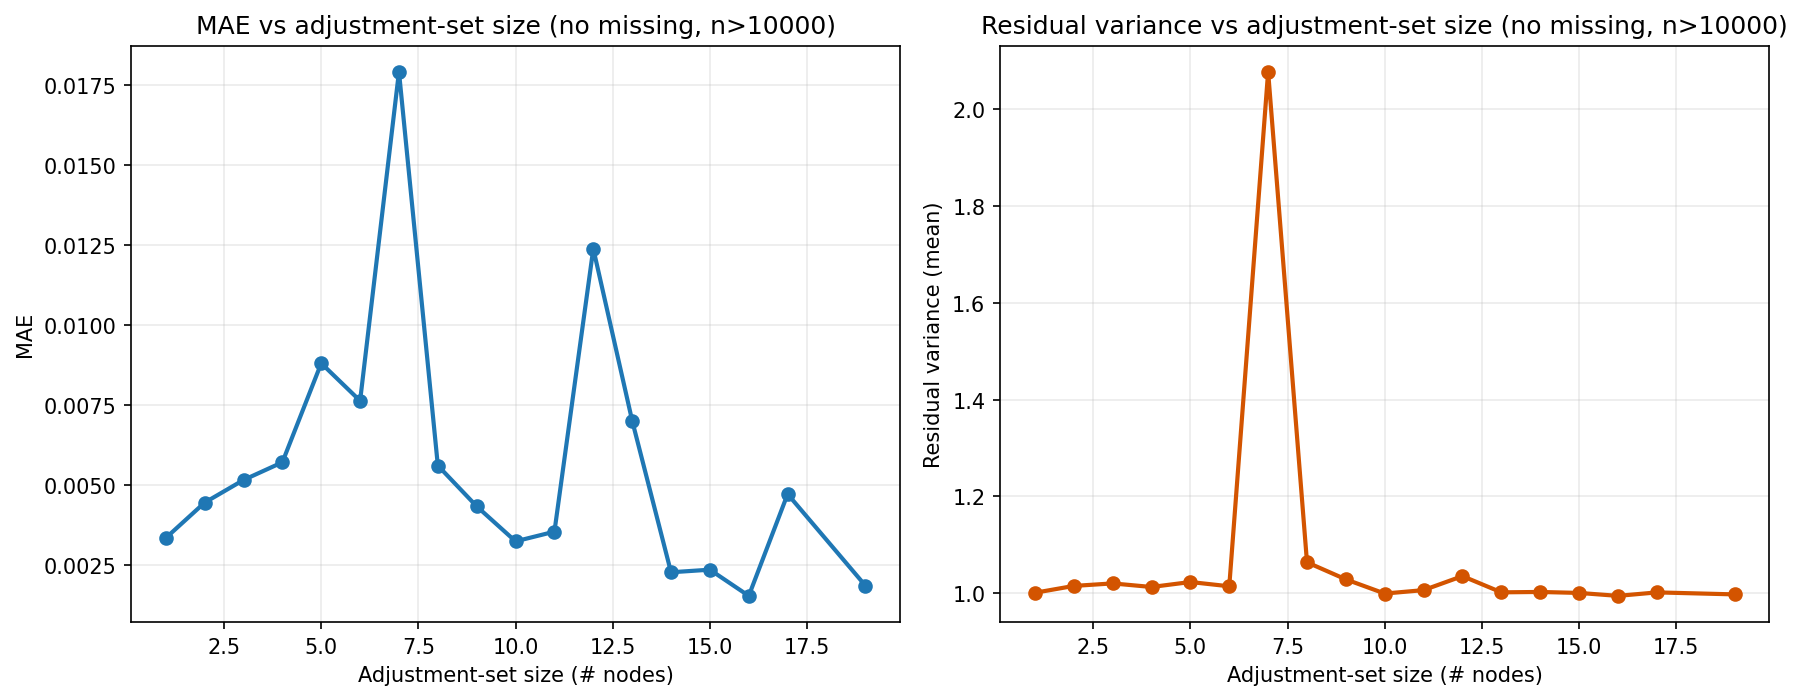

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_mae_resid_vs_adjustment_set_size_no_missing_n_gt10000.png


In [11]:
# Filter to rows with no missing edges, no missing data, and sample size > 10000
eval_filtered = eval_df[
    (eval_df["missing_edge_rate"] == 0)
    & (eval_df["missing_data_rate"] == 0)
    & (eval_df["n_samples"] > 10000)
].copy()

print(f"Filtered rows: {len(eval_filtered):,}")

# Compute adjustment-set size (uses adj_set_size defined earlier)
eval_filtered["adjustment_set_size"] = eval_filtered["adjustment_set"].apply(adj_set_size)
eval_filtered = eval_filtered.dropna(subset=["adjustment_set_size"])
eval_filtered["adjustment_set_size"] = eval_filtered["adjustment_set_size"].astype(int)

# Aggregate metrics by adjustment_set_size
adj_summary = (
    eval_filtered.groupby("adjustment_set_size", dropna=False)
    .agg(
        n=("error", "size"),
        MAE=("abs_error", "mean"),
        RMSE=("sq_error", lambda x: float(np.sqrt(np.mean(x)))),
        bias=("error", "mean"),
        residual_mean=("residual_variance", "mean"),
        residual_median=("residual_variance", "median"),
    )
    .reset_index()
    .sort_values("adjustment_set_size")
)

adj_csv = NB_DIR / "csd_estimation_adjustment_set_size_summary_no_missing_n_gt10000.csv"
adj_summary.to_csv(adj_csv, index=False)
print(f"Wrote adjustment-set-size summary: {adj_csv}")

display(adj_summary.head(20))

# Plot MAE and residual variance vs adjustment set size
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True)

axes[0].plot(adj_summary["adjustment_set_size"], adj_summary["MAE"], marker="o", linewidth=2)
axes[0].set_xlabel("Adjustment-set size (# nodes)")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE vs adjustment-set size (no missing, n>10000)")
axes[0].grid(True, alpha=0.25)

axes[1].plot(
    adj_summary["adjustment_set_size"],
    adj_summary["residual_mean"],
    marker="o",
    linewidth=2,
    color="#d35400",
)
axes[1].set_xlabel("Adjustment-set size (# nodes)")
axes[1].set_ylabel("Residual variance (mean)")
axes[1].set_title("Residual variance vs adjustment-set size (no missing, n>10000)")
axes[1].grid(True, alpha=0.25)

plt.tight_layout()
out = VIZ_DIR / "csd_estimation_mae_resid_vs_adjustment_set_size_no_missing_n_gt10000.png"
plt.savefig(out, dpi=150, bbox_inches="tight")
plt.close()

display(Image(str(out)))
print(f"Saved: {out}")


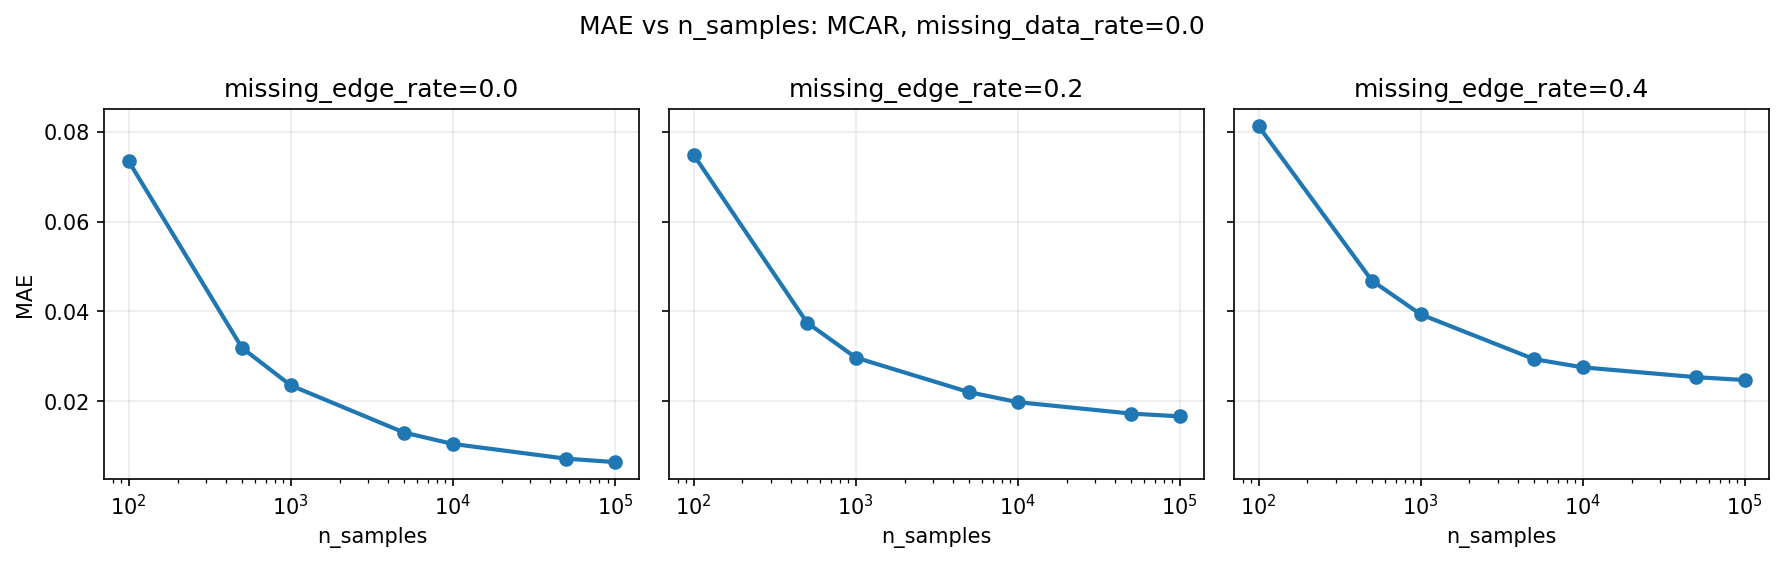

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_mae_lines_MCAR_data_rate0.0.png


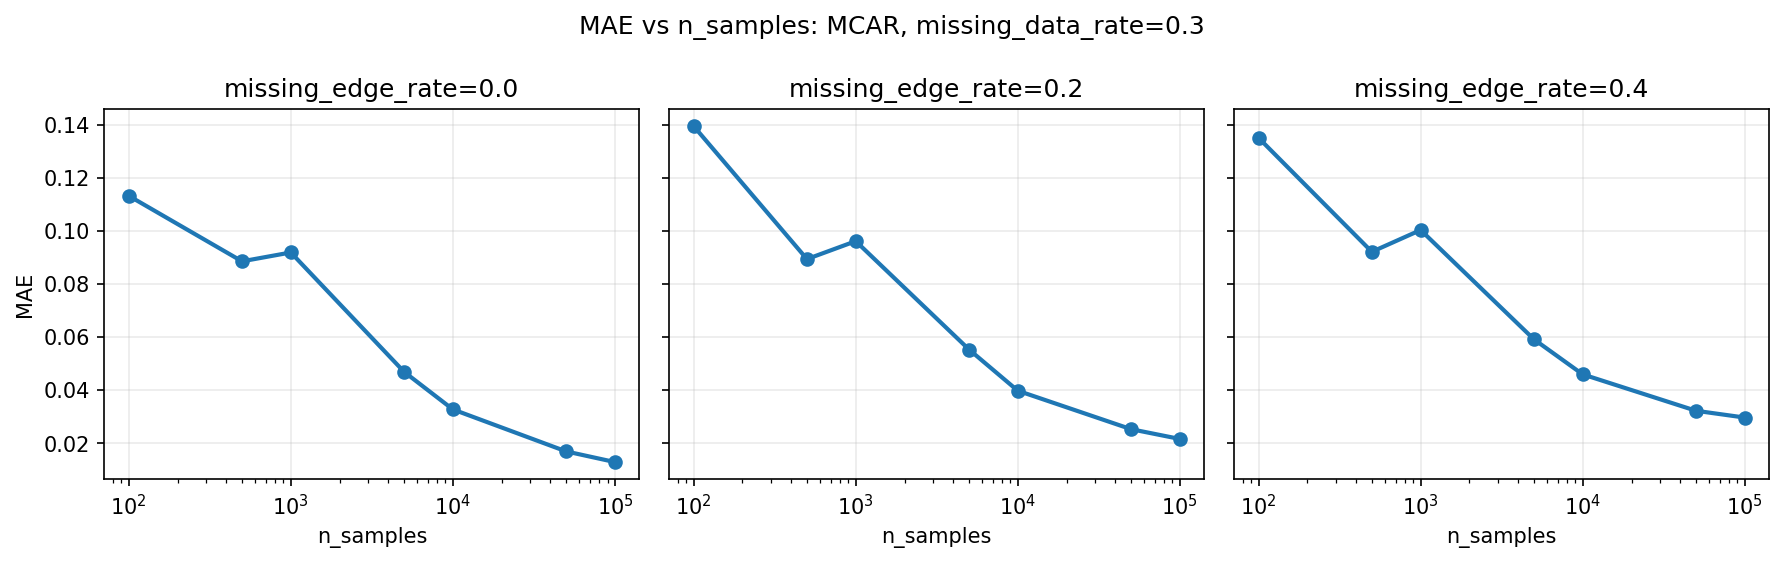

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_mae_lines_MCAR_data_rate0.3.png


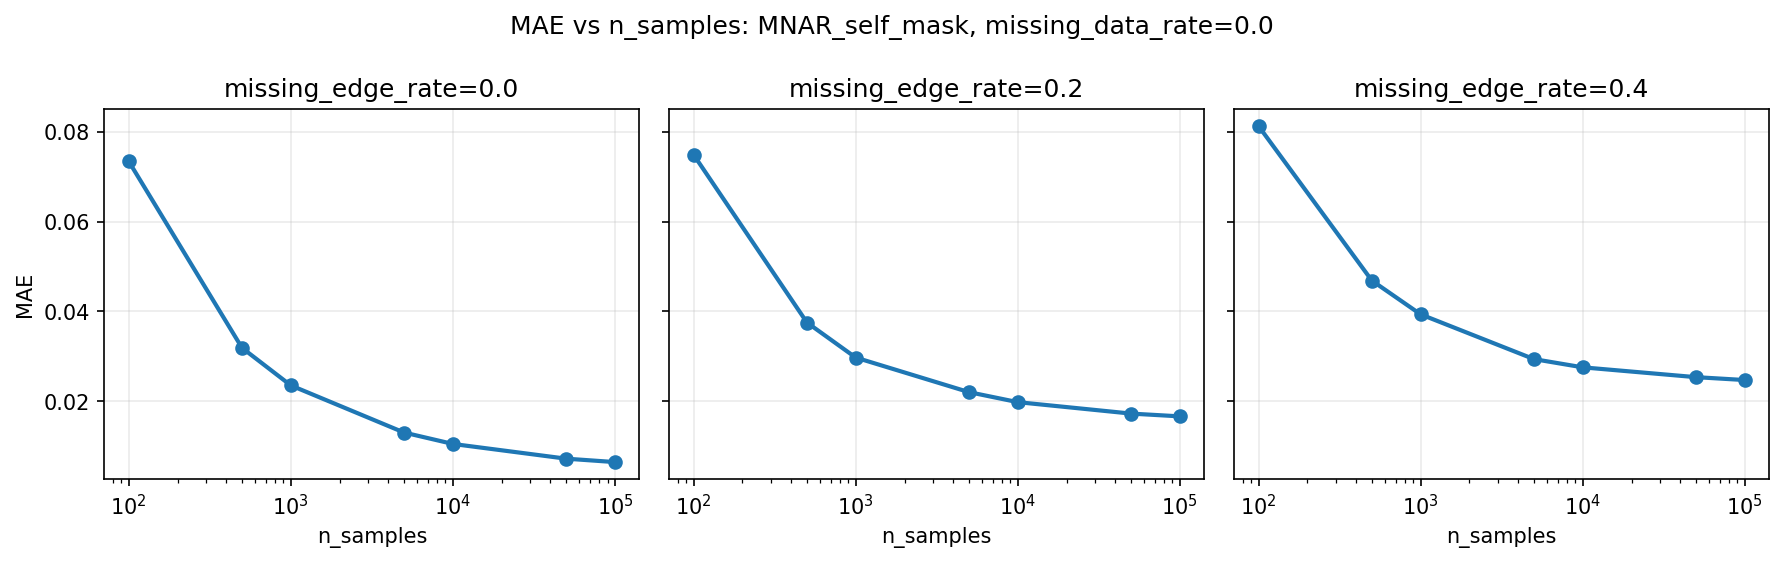

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_mae_lines_MNAR_self_mask_data_rate0.0.png


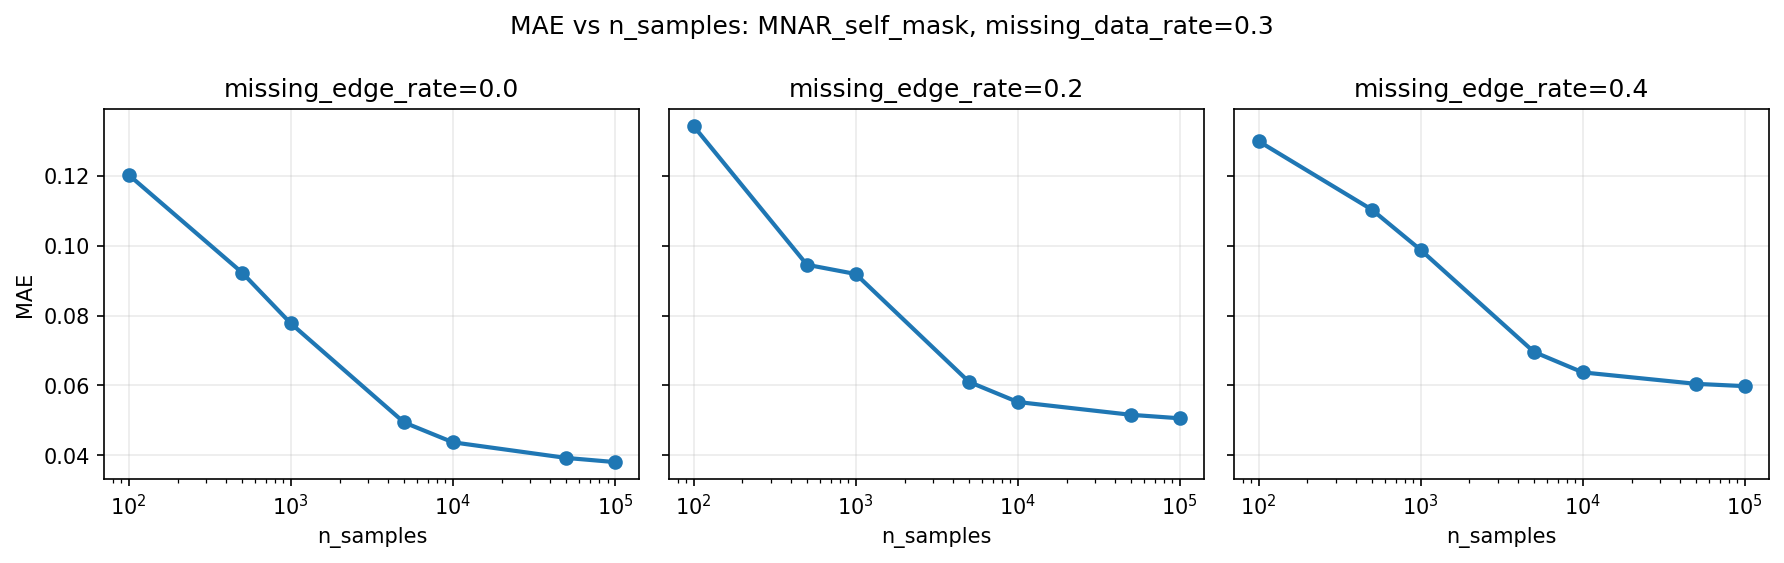

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_mae_lines_MNAR_self_mask_data_rate0.3.png


In [12]:
# Line plot: MAE vs n_samples for each missing_edge_rate (separate panels)

edge_rates = sorted(eval_df['missing_edge_rate'].unique())

mechs = sorted(eval_df['missing_data_mechanism'].unique())
data_rates = sorted(eval_df['missing_data_rate'].unique())

for mech in mechs:
    for dr in data_rates:
        sub = g[(g['missing_data_mechanism'] == mech) & (g['missing_data_rate'] == dr)].copy()
        if len(sub) == 0:
            continue

        sub = sub.sort_values(['missing_edge_rate', 'n_samples'])
        fig, axes = plt.subplots(
            1,
            len(edge_rates),
            figsize=(4.0 * len(edge_rates), 3.8),
            sharey=True,
        )
        if len(edge_rates) == 1:
            axes = [axes]

        for ax, er in zip(axes, edge_rates):
            s2 = sub[sub['missing_edge_rate'] == er]
            ax.plot(s2['n_samples'], s2['MAE'], marker='o', linewidth=2)
            ax.set_title(f'missing_edge_rate={er}')
            ax.set_xlabel('n_samples')
            ax.set_xscale('log')
            ax.grid(True, alpha=0.25)

        axes[0].set_ylabel('MAE')
        fig.suptitle(f'MAE vs n_samples: {mech}, missing_data_rate={dr}')
        plt.tight_layout()

        out = VIZ_DIR / f'csd_estimation_mae_lines_{mech}_data_rate{dr}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.close()

        display(Image(str(out)))
        print(f'Saved: {out}')


## 3) How residual variance changes with parameters

In [13]:
resid_group_cols = [
    'missing_data_mechanism',
    'missing_data_rate',
    'missing_edge_rate',
    'n_samples',
]

res = (
    eval_df.groupby(resid_group_cols, dropna=False)
    .agg(
        n=('residual_variance', 'size'),
        residual_mean=('residual_variance', 'mean'),
        residual_median=('residual_variance', 'median'),
        residual_std=('residual_variance', 'std'),
    )
    .reset_index()
)

res_csv = NB_DIR / 'csd_estimation_residual_variance_summary.csv'
res.to_csv(res_csv, index=False)
print(f'Wrote residual variance summary: {res_csv}')


Wrote residual variance summary: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/csd_estimation_residual_variance_summary.csv


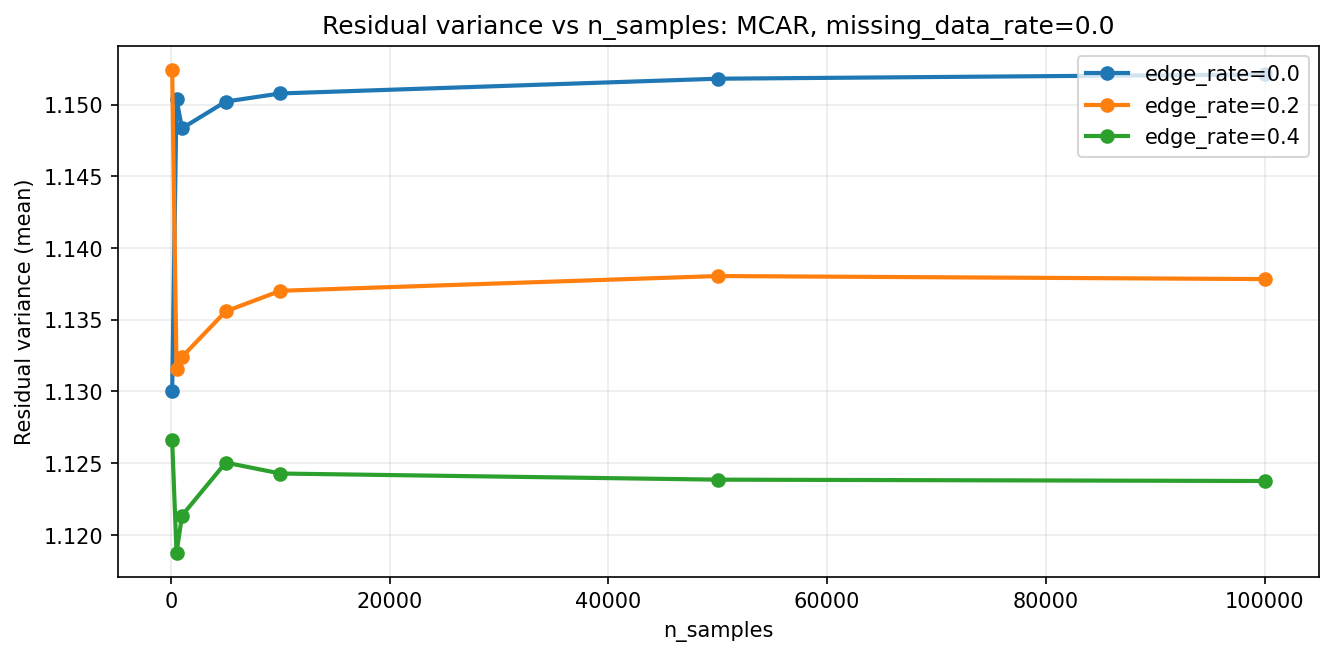

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_vs_n_MCAR_data_rate0.0.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


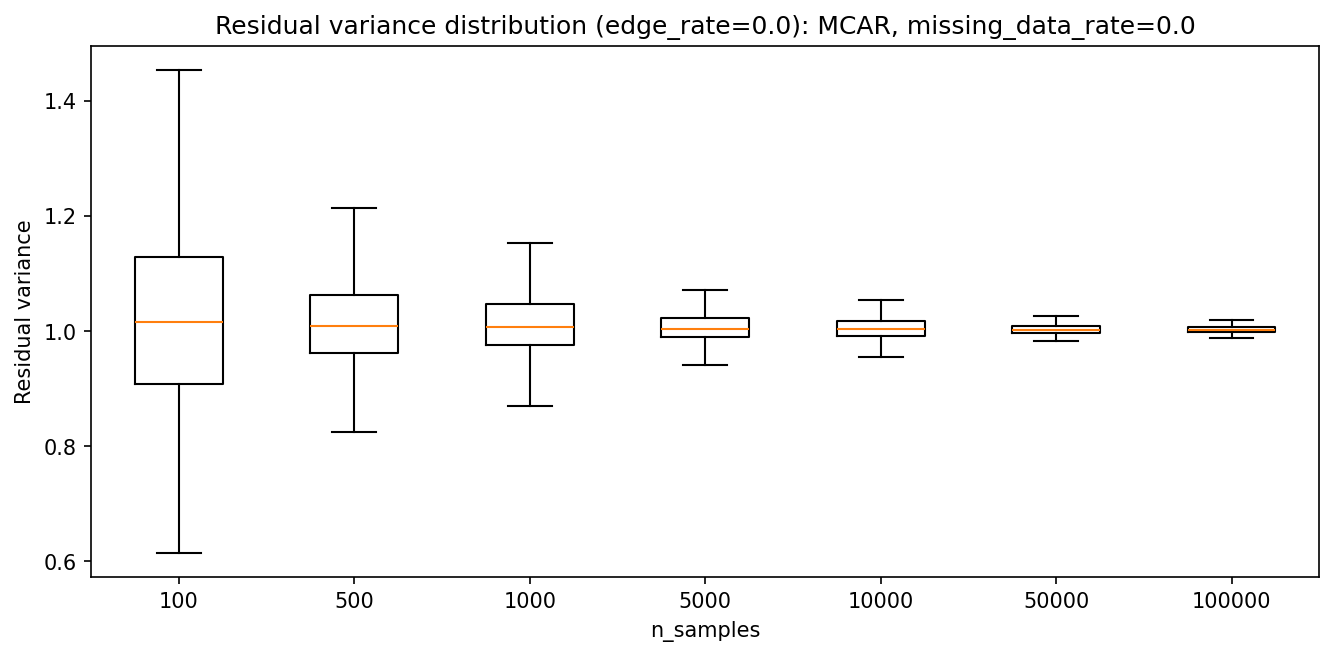

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MCAR_data_rate0.0_edge0.0.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


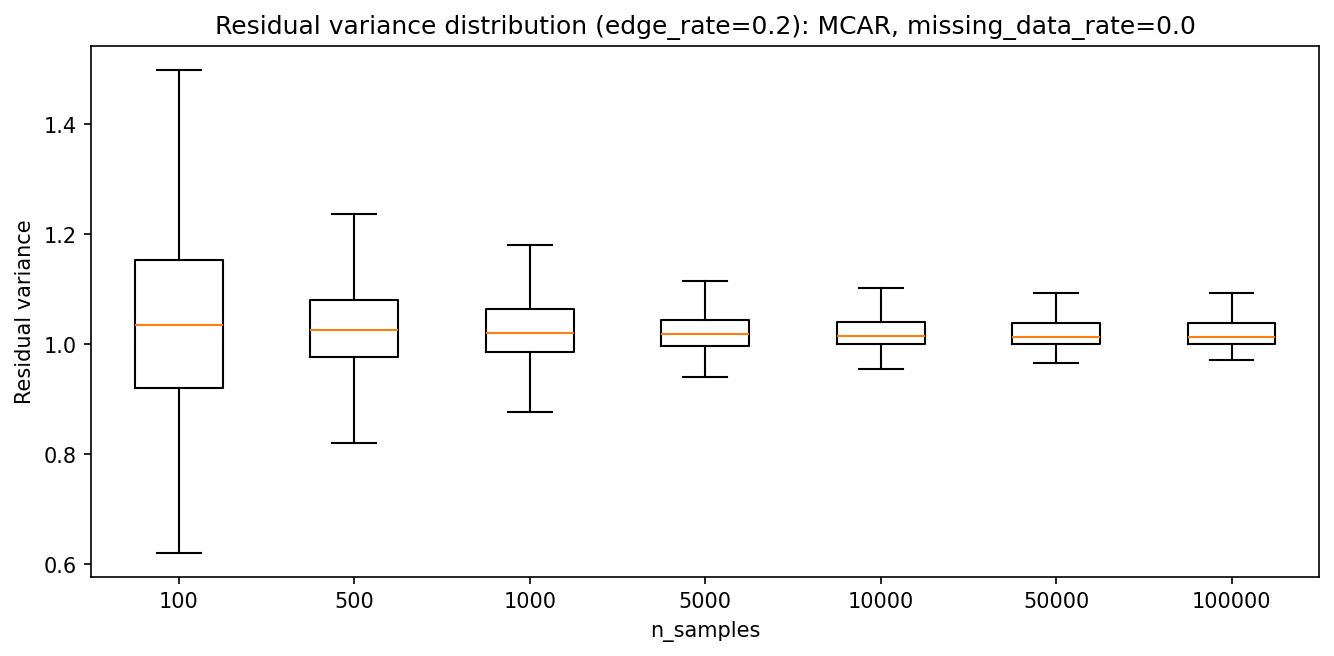

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MCAR_data_rate0.0_edge0.2.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


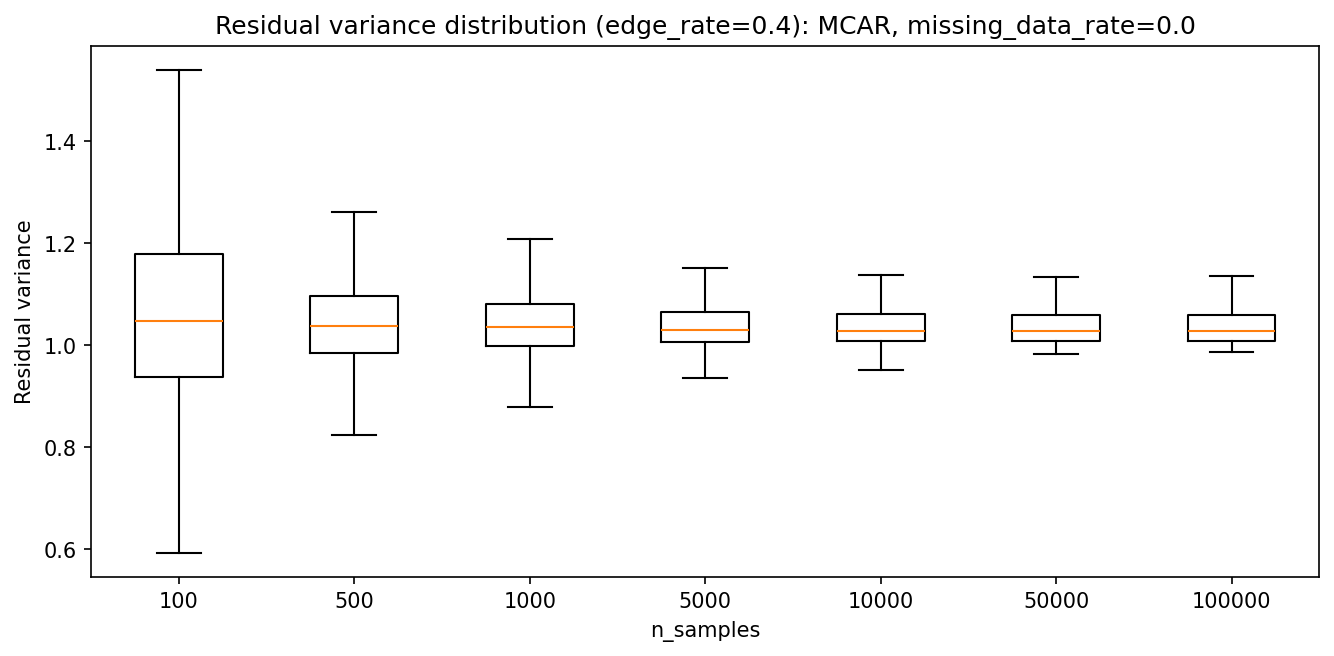

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MCAR_data_rate0.0_edge0.4.png


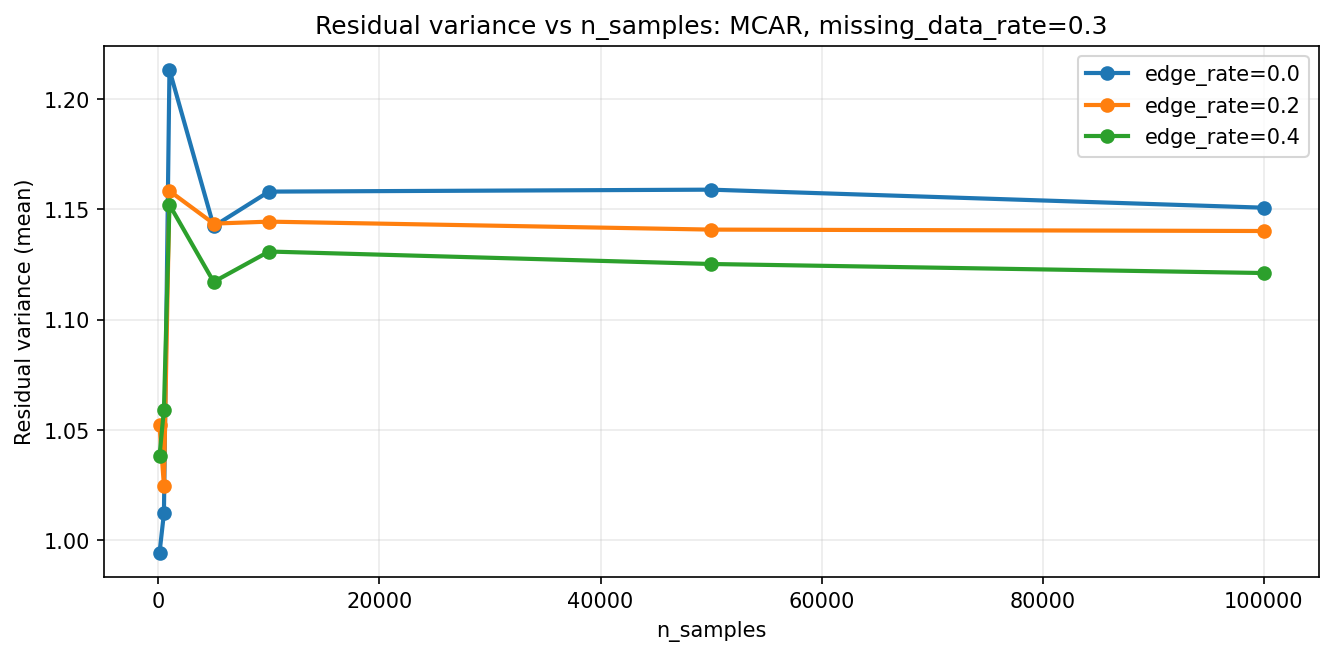

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_vs_n_MCAR_data_rate0.3.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


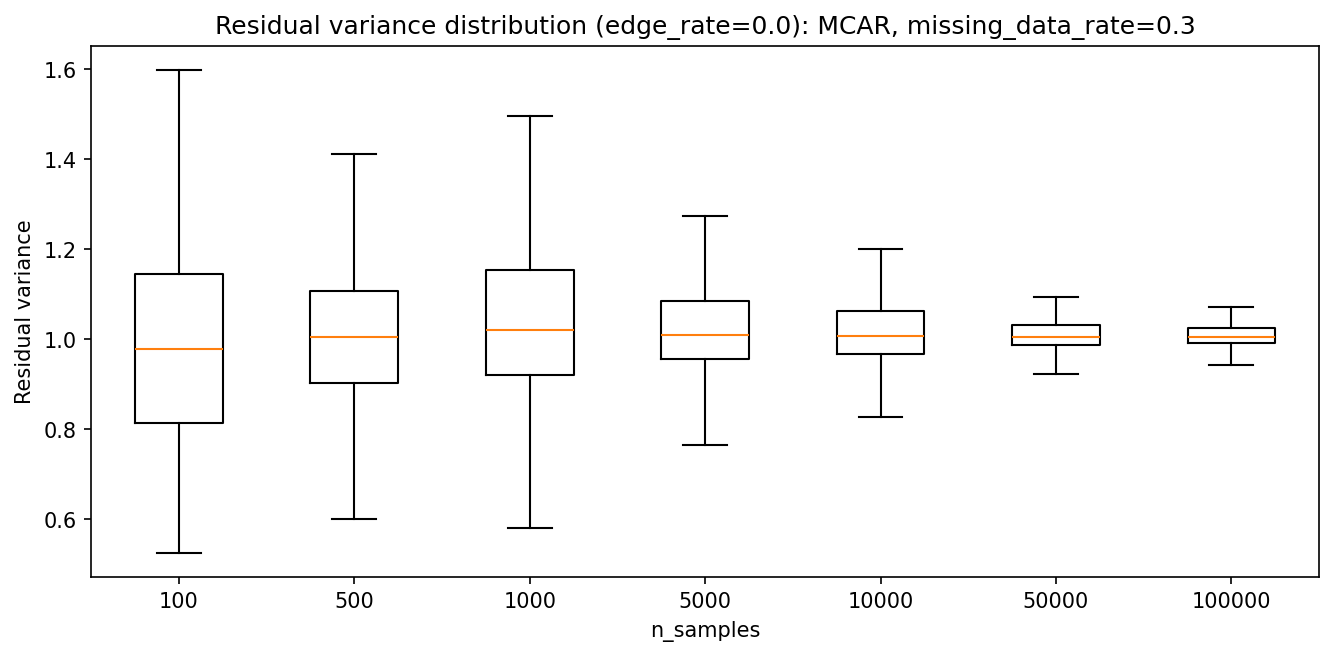

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MCAR_data_rate0.3_edge0.0.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


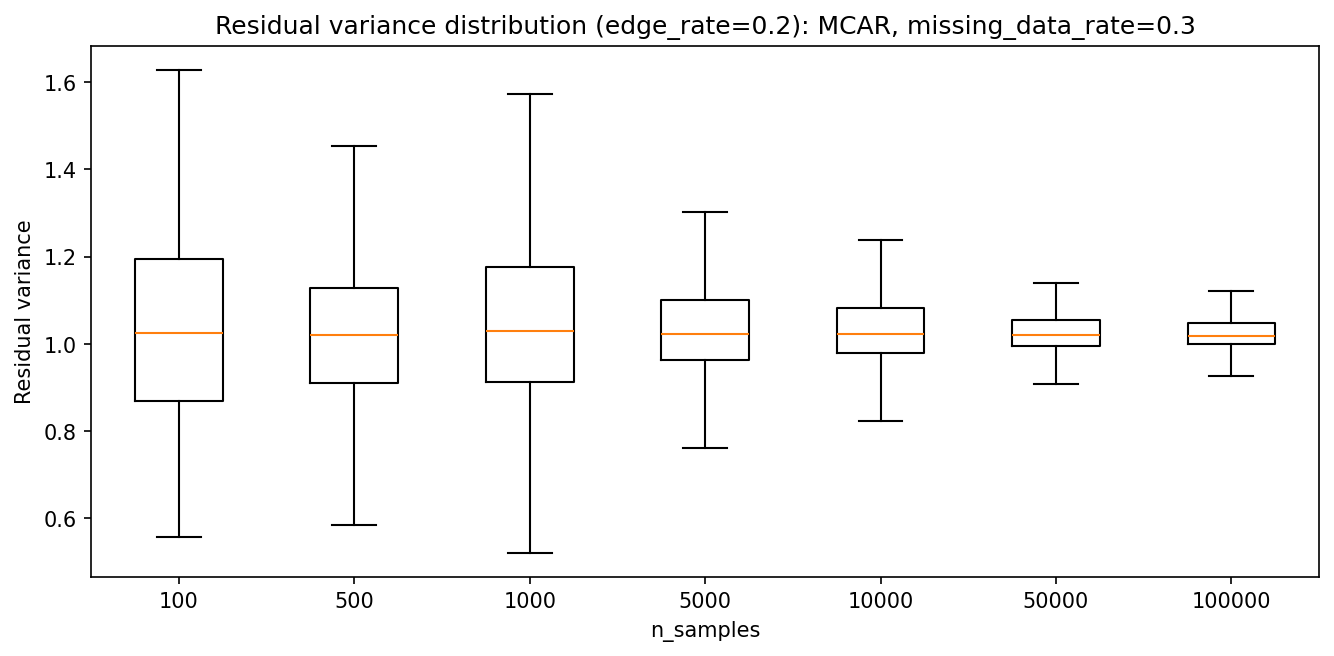

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MCAR_data_rate0.3_edge0.2.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


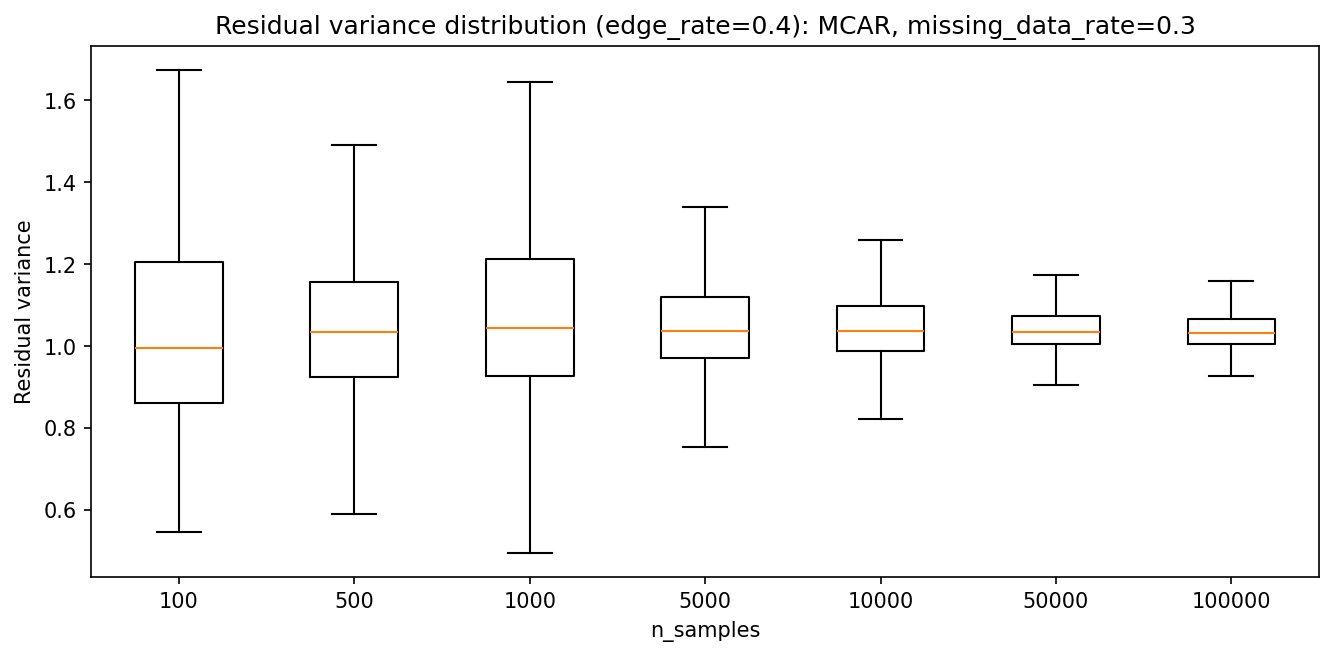

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MCAR_data_rate0.3_edge0.4.png


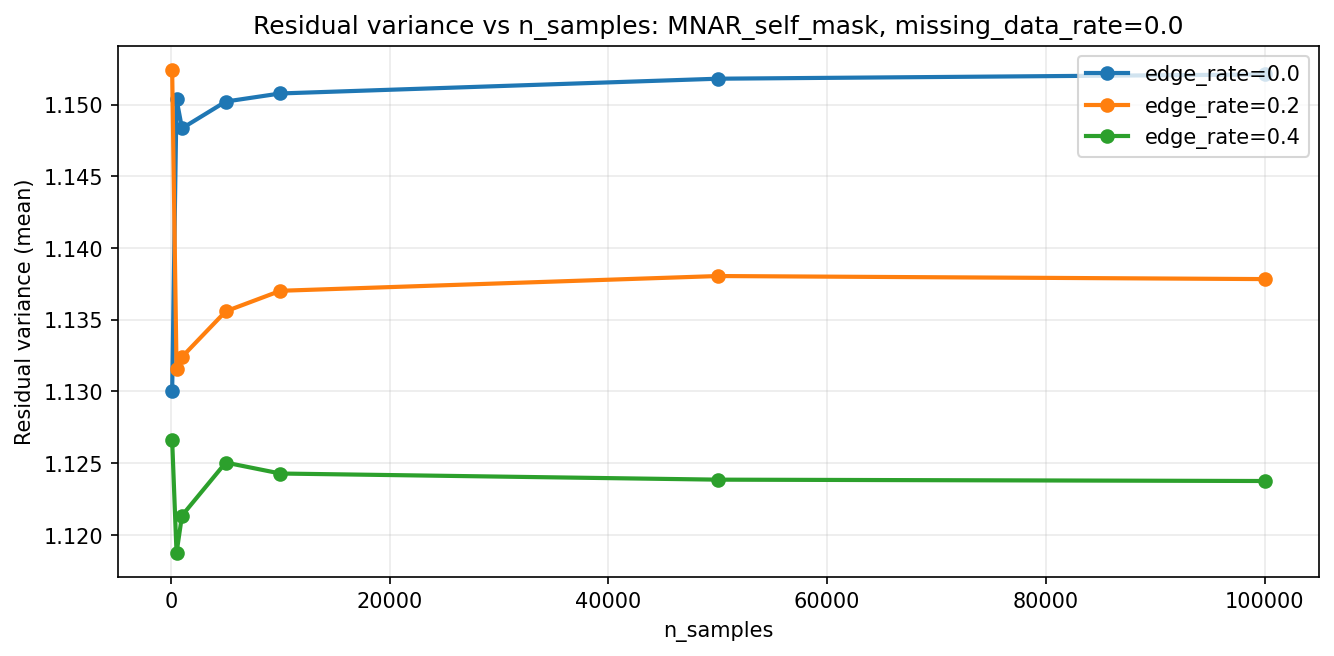

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_vs_n_MNAR_self_mask_data_rate0.0.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


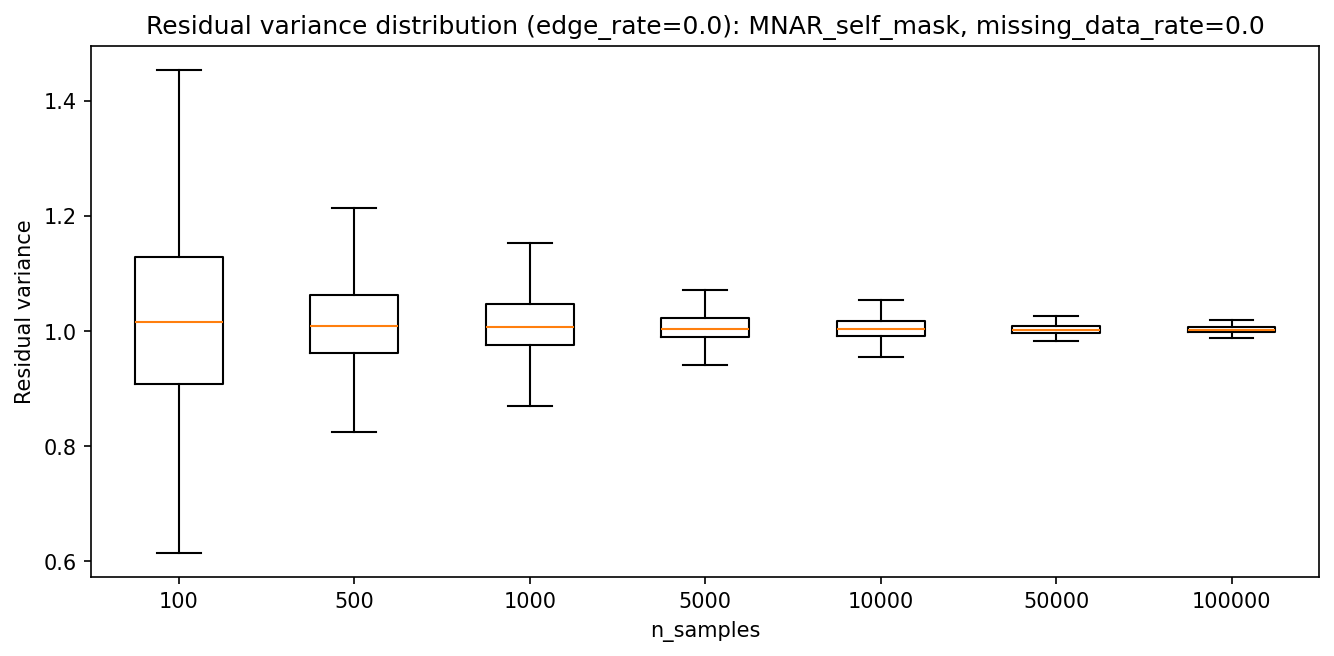

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MNAR_self_mask_data_rate0.0_edge0.0.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


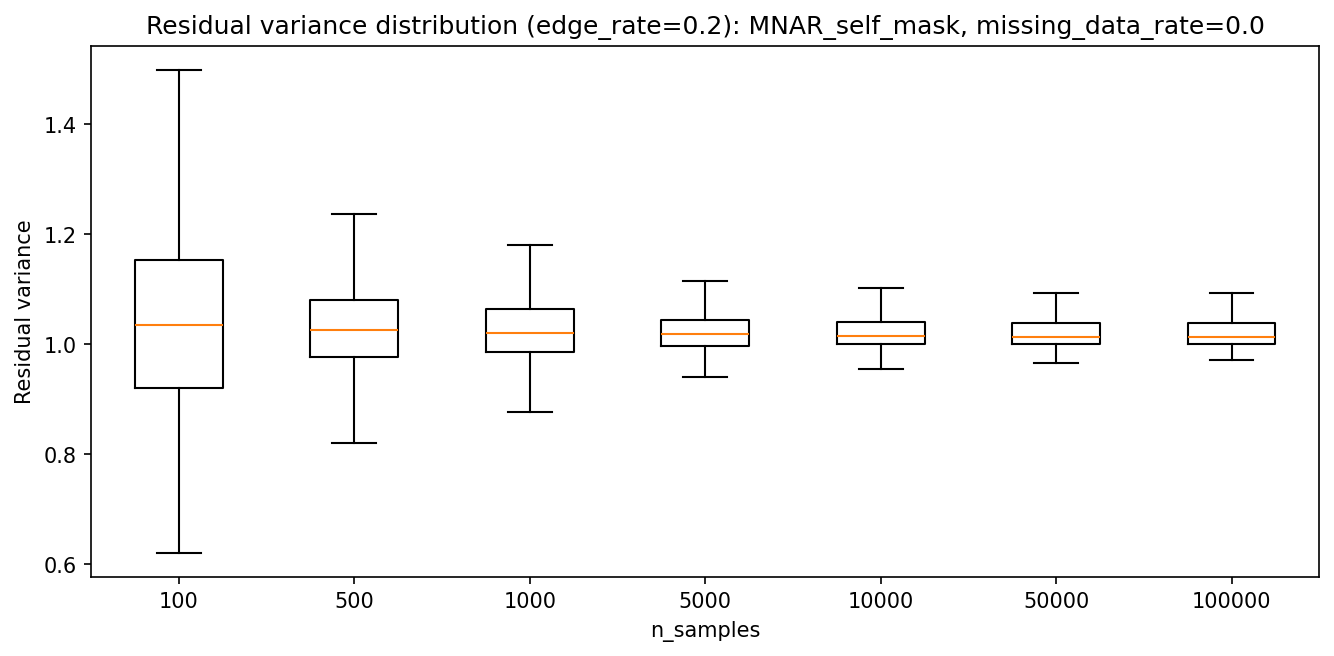

/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MNAR_self_mask_data_rate0.0_edge0.2.png


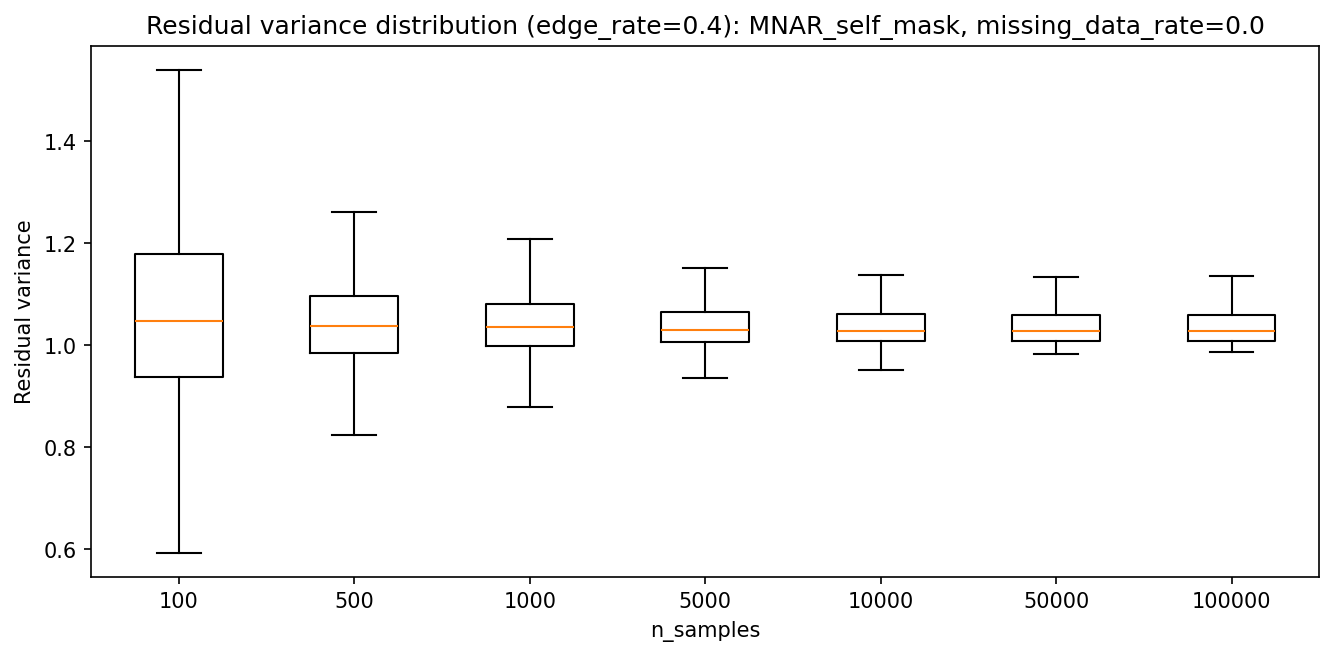

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MNAR_self_mask_data_rate0.0_edge0.4.png


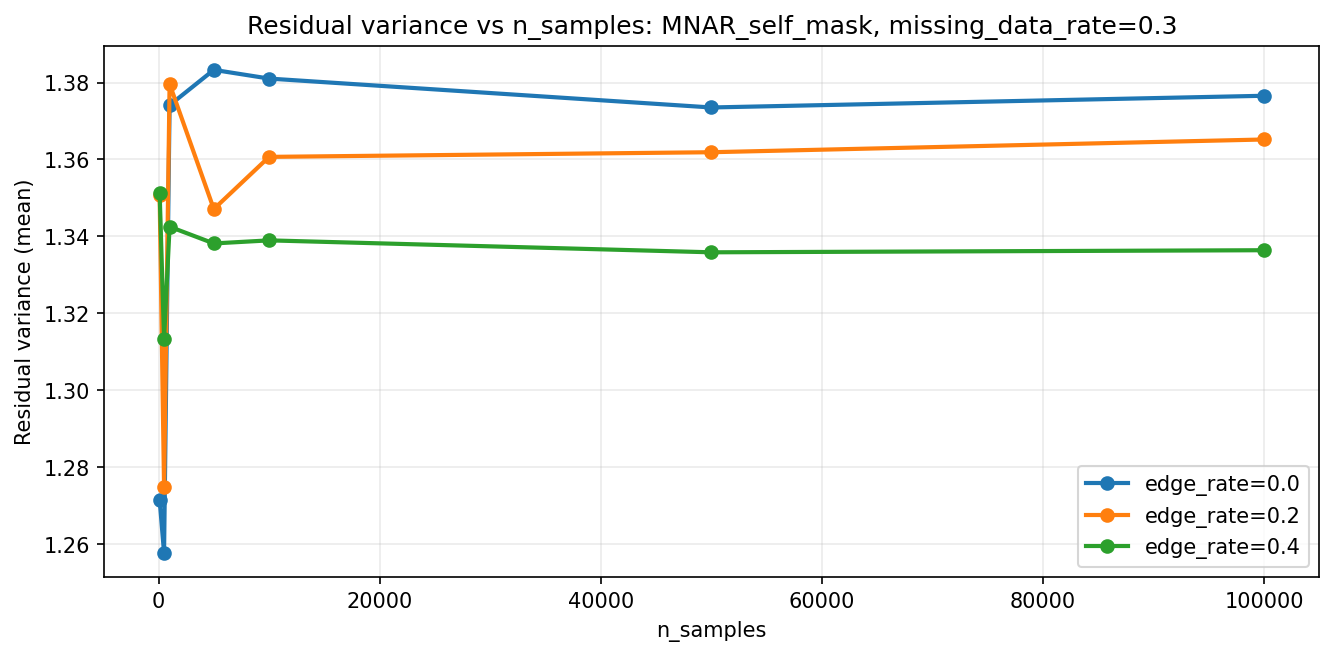

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_vs_n_MNAR_self_mask_data_rate0.3.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


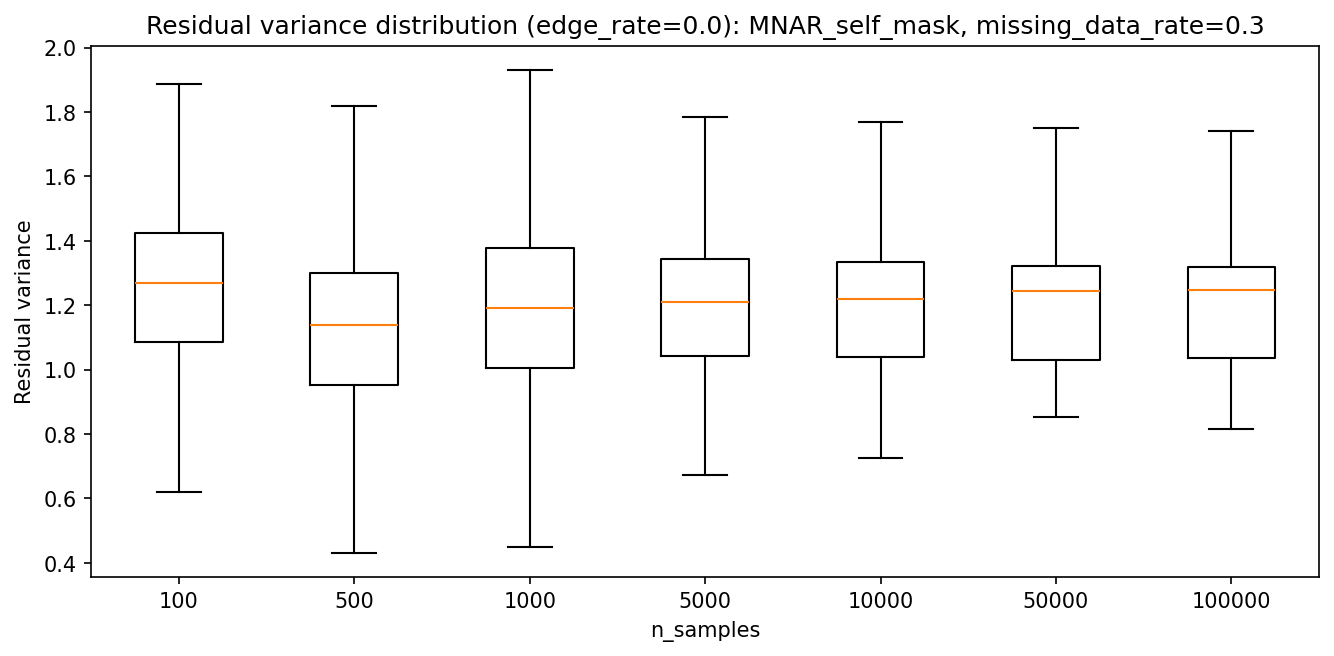

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MNAR_self_mask_data_rate0.3_edge0.0.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


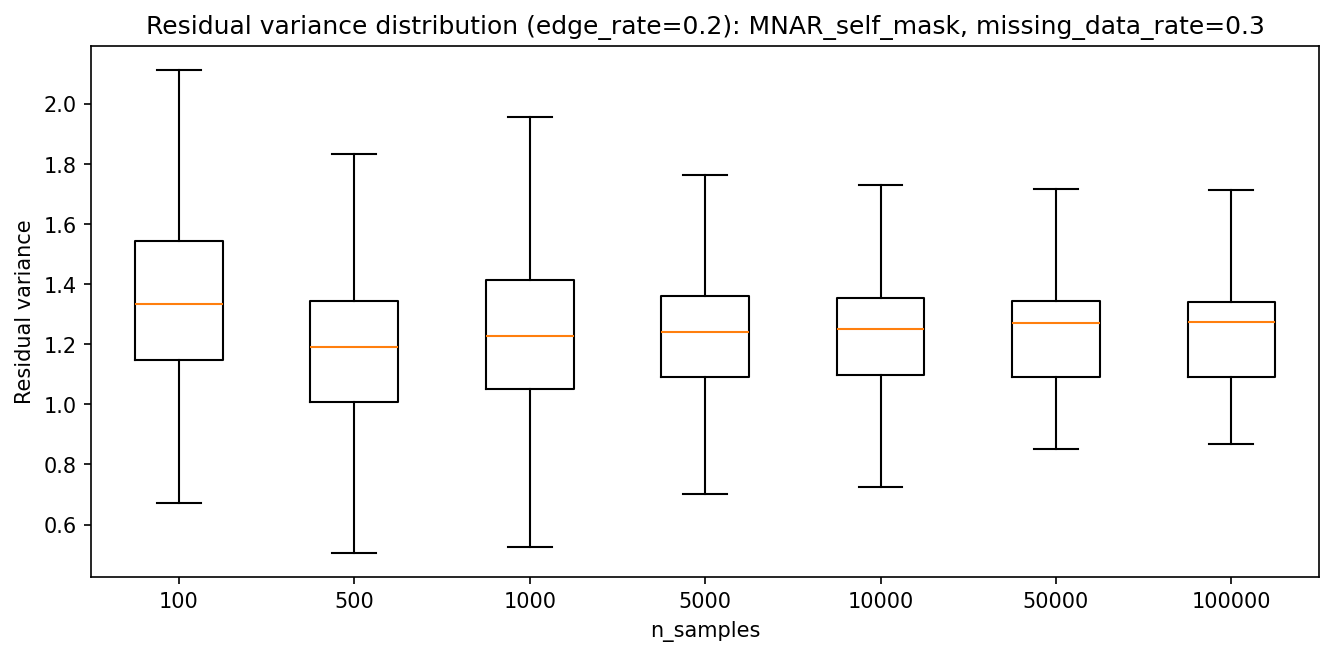

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MNAR_self_mask_data_rate0.3_edge0.2.png


/tmp/ipykernel_5458/2514832961.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)


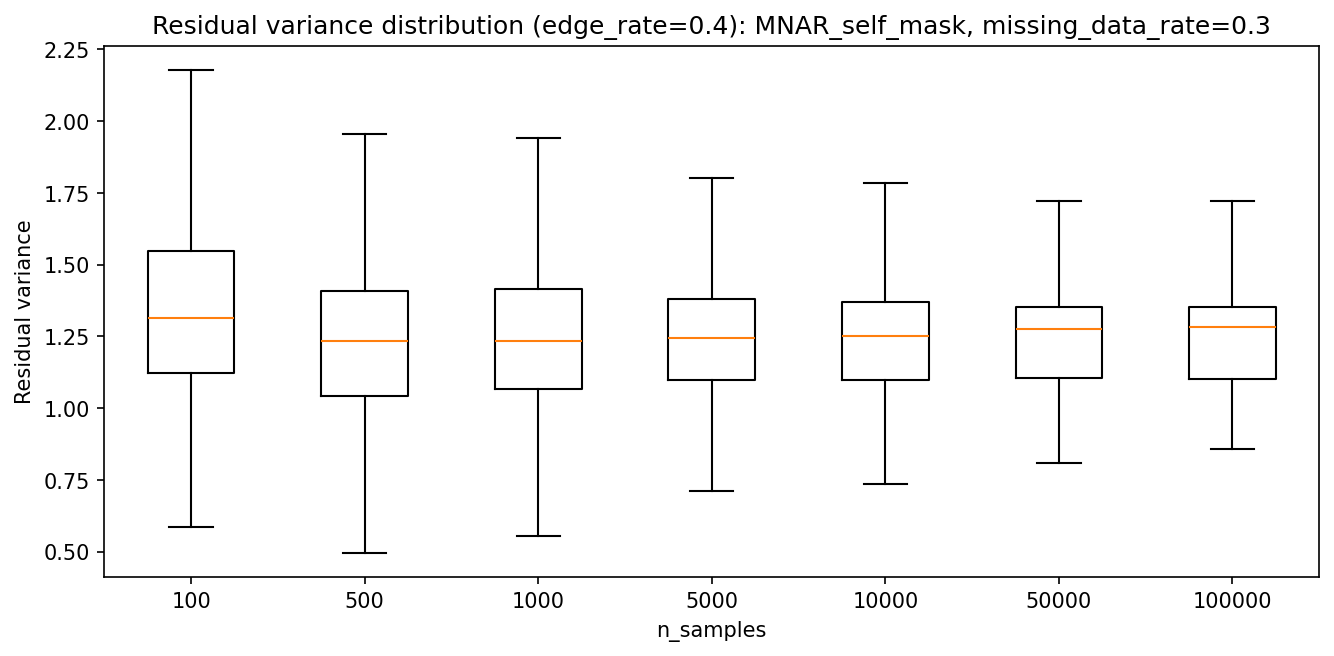

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_box_MNAR_self_mask_data_rate0.3_edge0.4.png


In [14]:
# Line plot residual variance vs n_samples (residual mean), plus one boxplot per setting.
plot_df = eval_df.dropna(subset=['residual_variance', 'n_samples']).copy()

for mech in sorted(plot_df['missing_data_mechanism'].unique()):
    for dr in sorted(plot_df['missing_data_rate'].unique()):
        sub = plot_df[
            (plot_df['missing_data_mechanism'] == mech) & (plot_df['missing_data_rate'] == dr)
        ].copy()
        if len(sub) == 0:
            continue

        edge_rates_sorted = sorted(sub['missing_edge_rate'].unique())
        ns_sorted = sorted(sub['n_samples'].unique())

        # Mean residual variance lines
        fig, ax = plt.subplots(figsize=(9, 4.5))
        for er in edge_rates_sorted:
            s2 = res[
                (res['missing_data_mechanism'] == mech)
                & (res['missing_data_rate'] == dr)
                & (res['missing_edge_rate'] == er)
            ].sort_values('n_samples')
            ax.plot(
                s2['n_samples'],
                s2['residual_mean'],
                marker='o',
                linewidth=2,
                label=f'edge_rate={er}',
            )

        ax.set_xlabel('n_samples')
        ax.set_ylabel('Residual variance (mean)')
        ax.set_title(f'Residual variance vs n_samples: {mech}, missing_data_rate={dr}')
        ax.grid(True, alpha=0.25)
        ax.legend()
        plt.tight_layout()

        out = VIZ_DIR / f'csd_estimation_residual_vs_n_{mech}_data_rate{dr}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        plt.close()
        display(Image(str(out)))
        print(f'Saved: {out}')

        # Distribution via boxplot for the edge-rates
        for er in edge_rates:
            box_sub = sub[sub['missing_edge_rate'] == er]
            if len(box_sub) > 0:
                data_by_n = [
                    box_sub[box_sub['n_samples'] == n]['residual_variance'].dropna().values
                    for n in ns_sorted
                ]
                fig2, ax2 = plt.subplots(figsize=(9, 4.5))
                ax2.boxplot(data_by_n, labels=[str(n) for n in ns_sorted], showfliers=False)
                ax2.set_xlabel('n_samples')
                ax2.set_ylabel('Residual variance')
                ax2.set_title(
                    f'Residual variance distribution (edge_rate={er}): {mech}, missing_data_rate={dr}'
                )
                plt.tight_layout()
                out2 = VIZ_DIR / f'csd_estimation_residual_box_{mech}_data_rate{dr}_edge{er}.png'
                plt.savefig(out2, dpi=150, bbox_inches='tight')
                plt.close()
                display(Image(str(out2)))
                print(f'Saved: {out2}')


## 4) Residual variance vs estimation error

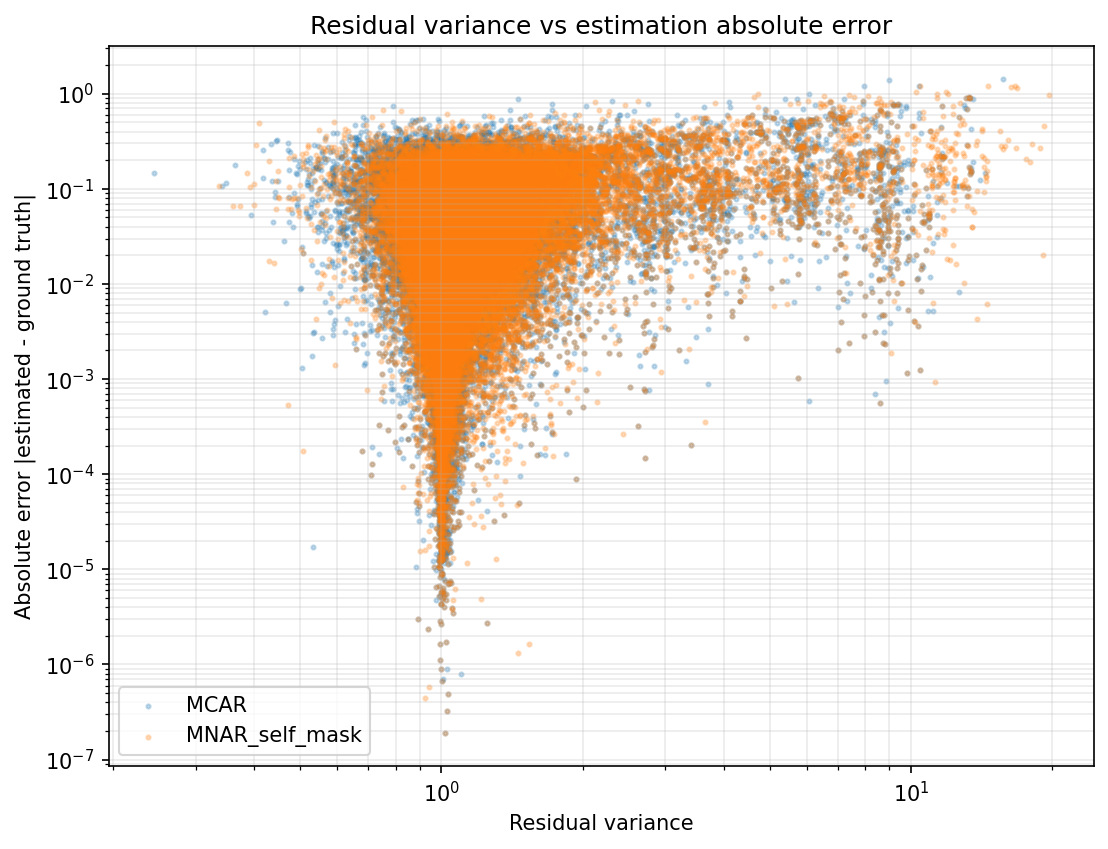

Saved: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/visualizations/csd_estimation_residual_vs_abs_error.png


In [15]:
plot_df = eval_df.dropna(subset=['residual_variance', 'abs_error', 'missing_data_mechanism']).copy()

fig, ax = plt.subplots(figsize=(7.5, 5.8))
for mech in sorted(plot_df['missing_data_mechanism'].unique()):
    s2 = plot_df[plot_df['missing_data_mechanism'] == mech]
    ax.scatter(
        s2['residual_variance'],
        s2['abs_error'],
        s=4,
        alpha=0.25,
        label=mech,
        rasterized=True,
    )

ax.set_xlabel('Residual variance')
ax.set_ylabel('Absolute error |estimated - ground truth|')
ax.set_title('Residual variance vs estimation absolute error')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, which='both', alpha=0.25)
ax.legend()

plt.tight_layout()
out = VIZ_DIR / 'csd_estimation_residual_vs_abs_error.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.close()

display(Image(str(out)))
print(f'Saved: {out}')


In [16]:
# Correlation summary per setting (helps interpret residual changes)
def corr_safe(x: pd.Series, y: pd.Series) -> float:
    if len(x) < 3:
        return float('nan')
    return float(np.corrcoef(x, y)[0, 1])

link = (
    eval_df.groupby(['missing_data_mechanism', 'missing_data_rate', 'missing_edge_rate', 'n_samples'], dropna=False)
    .apply(lambda d: pd.Series({
        'corr_resid_vs_abs_error': corr_safe(d['residual_variance'].fillna(0.0), d['abs_error'].fillna(0.0)),
        'residual_mean': float(d['residual_variance'].mean()),
        'MAE': float(d['abs_error'].mean()),
        'n': len(d),
    }))
    .reset_index()
)

link_csv = NB_DIR / 'csd_estimation_residual_vs_error_link_summary.csv'
link.to_csv(link_csv, index=False)
print(f'Wrote link summary: {link_csv}')

print('Top 10 settings by residual_mean:')
display(link.sort_values('residual_mean', ascending=False).head(10))


Wrote link summary: /home/colin/nocap/notebooks/Ecoli_Analysis_Notebooks/estimation/20260713_182423/csd_estimation_residual_vs_error_link_summary.csv
Top 10 settings by residual_mean:


/tmp/ipykernel_5458/1690640622.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda d: pd.Series({


,missing_data_mechanism,missing_data_rate,missing_edge_rate,n_samples,corr_resid_vs_abs_error,residual_mean,MAE,n
66,MNAR_self_mask,0.3,0.0,5000,0.488582,1.383290,0.049421,2533.0
67,MNAR_self_mask,0.3,0.0,10000,0.503185,1.381028,0.043730,2533.0
72,MNAR_self_mask,0.3,0.2,1000,0.389357,1.379632,0.091936,2533.0
69,MNAR_self_mask,0.3,0.0,100000,0.575766,1.376559,0.038062,2533.0
65,MNAR_self_mask,0.3,0.0,1000,0.214529,1.374099,0.077780,2533.0
68,MNAR_self_mask,0.3,0.0,50000,0.610787,1.373518,0.039255,2533.0
76,MNAR_self_mask,0.3,0.2,100000,0.557493,1.365198,0.050603,2533.0
75,MNAR_self_mask,0.3,0.2,50000,0.560115,1.361887,0.051600,2533.0
74,MNAR_self_mask,0.3,0.2,10000,0.450892,1.360677,0.055266,2533.0
77,MNAR_self_mask,0.3,0.4,100,0.740383,1.351400,0.129979,2535.0
